In [1]:
%pip install chronos-forecasting -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 89.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
!git clone https://github.com/google-research/timesfm.git
%cd timesfm
%pip install -e .

Cloning into 'timesfm'...
remote: Enumerating objects: 1528, done.
remote: Counting objects: 100% (845/845), done.
remote: Compressing objects: 100% (415/415), done.
remote: Total 1528 (delta 574), reused 430 (delta 430), pack-reused 683 (from 2)
Receiving objects: 100% (1528/1528), 4.10 MiB | 20.66 MiB/s, done.
Resolving deltas: 100% (799/799), done.
Encountered 4 file(s) that should have been pointers, but weren't:
	timesfm-forecasting/examples/anomaly-detection/output/anomaly_detection.png
	timesfm-forecasting/examples/covariates-forecasting/output/covariates_data.png
	timesfm-forecasting/examples/global-temperature/output/forecast_animation.gif
	timesfm-forecasting/examples/global-temperature/output/forecast_visualization.png
/kaggle/working/timesfm
Obtaining file:///kaggle/working/timesfm
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.to

In [3]:
import sys
sys.path.append('/kaggle/working')
from timesfm.src import timesfm
print(timesfm.__file__)

/kaggle/working/timesfm/src/timesfm/__init__.py


In [4]:
# ===== timesfm PATCH FIX =====
import inspect
from timesfm.src.timesfm import TimesFM_2p5_200M_torch as cls

# patch 1 lần duy nhất
if not hasattr(cls, "_patched_safe_init"):

    orig_init = cls.__init__
    sig = inspect.signature(orig_init)
    valid_params = set(sig.parameters.keys())

    def new_init(self, *args, **kwargs):
        # lọc kwargs hợp lệ
        filtered_kwargs = {
            k: v for k, v in kwargs.items()
            if k in valid_params
        }
        return orig_init(self, *args, **filtered_kwargs)

    cls.__init__ = new_init
    cls._patched_safe_init = True

    print('timesfm patch fixed !')
# ============================

timesfm patch fixed !


In [5]:
# Import

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('..') 
import os

In [6]:
class DataLoader:
    """
    Loads and standardizes all raw data tables from the competition dataset.

    Handles column renaming, date parsing, and basic type coercion so that
    all downstream classes receive clean, consistently named DataFrames.
    """

    def __init__(self, raw_data_path: str):
        self.raw_data_path = raw_data_path

    def load_all_data(self) -> dict:
        data = {}
        data['sales']       = self._load_sales()
        data['promotions']  = self._load_promotions()
        data['web_traffic'] = self._load_web_traffic()
        return data

    # --------------------------------------------------------------------------
    # LOADERS
    # --------------------------------------------------------------------------

    def _load_sales(self) -> pd.DataFrame:
        path = os.path.join(self.raw_data_path, 'sales.csv')
        df   = pd.read_csv(path)

        df.columns = df.columns.str.strip().str.lower()
        df = df.rename(columns={
            'date'   : 'date',
            'revenue': 'revenue',
            'cogs'   : 'cogs',
        })

        df['date']    = pd.to_datetime(df['date'])
        df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce').fillna(0)
        df['cogs']    = pd.to_numeric(df['cogs'],    errors='coerce').fillna(0)

        df = df.sort_values('date').reset_index(drop=True)

        print(f"Sales loaded       : {len(df):,} rows | "
              f"{df['date'].min().date()} -> {df['date'].max().date()}")
        return df

    def _load_promotions(self) -> pd.DataFrame:
        path = os.path.join(self.raw_data_path, 'promotions.csv')
        df   = pd.read_csv(path)

        df.columns = df.columns.str.strip().str.lower()
        df = df.rename(columns={
            'start_date'     : 'start_date',
            'end_date'       : 'end_date',
            'discount_value' : 'discount_value',
            'stackable_flag' : 'stackable_flag',
        })

        df['start_date'] = pd.to_datetime(df['start_date'])
        df['end_date']   = pd.to_datetime(df['end_date'])

        print(f"Promotions loaded  : {len(df):,} rows")
        return df

    def _load_web_traffic(self) -> pd.DataFrame:
        path = os.path.join(self.raw_data_path, 'web_traffic.csv')
        df   = pd.read_csv(path)

        df.columns = df.columns.str.strip().str.lower()
        df['date'] = pd.to_datetime(df['date'])

        print(f"Web traffic loaded : {len(df):,} rows")
        return df

In [7]:
# =========================
# CONSTANTS
# =========================

TET_DATES = {
    2013: '2013-02-10', 2014: '2014-01-31', 2015: '2015-02-19',
    2016: '2016-02-08', 2017: '2017-01-28', 2018: '2018-02-16',
    2019: '2019-02-05', 2020: '2020-01-25', 2021: '2021-02-12',
    2022: '2022-02-01', 2023: '2023-01-22', 2024: '2024-02-10',
}

# Promo schedule derived from historical promotions table
# Format: (name, start_month, start_day, duration_days, discount_pct, recurrence)
# recurrence: True = every year, 'odd' = odd years only
PROMO_SCHEDULE = [
    ('spring_sale',    3,  18, 30, 12,   True),
    ('mid_year',       6,  23, 29, 18,   True),
    ('fall_launch',    8,  30, 32, 10,   True),
    ('year_end',       11, 18, 45, 20,   True),
    ('urban_blowout',  7,  30, 33, None, 'odd'),  # odd years only
    ('rural_special',  1,  30, 30, 15,   'odd'),  # odd years only
]

# Vietnamese fixed-date holidays + commercial events
VN_FIXED_HOLIDAYS = [
    (1,  1,  'new_year'),
    (3,  8,  'womens_day'),
    (4,  30, 'reunification'),
    (5,  1,  'labor_day'),
    (9,  2,  'national_day'),
    (10, 20, 'vn_womens_day'),
    (11, 11, 'dd_1111'),
    (12, 12, 'dd_1212'),
    (12, 24, 'christmas_eve'),
    (12, 25, 'christmas'),
]


class FeatureEngineer:
    """
    Feature Engineering chuẩn long-term forecasting.
    Pure calendar features — fully future-safe, no lag, no rolling.
    All features computable from date alone → test matrix buildable upfront.

    Replaces old run_pipeline() with build_features(dates) which accepts
    any DatetimeIndex and returns the full feature matrix for those dates.
    """

    def __init__(self, sales_df):
        self.sales_df = sales_df.copy()

        # Pre-build Tet lookup: year → pd.Timestamp
        self._tet_lut = {
            yr: pd.Timestamp(dt) for yr, dt in TET_DATES.items()
        }

    # =========================
    # PUBLIC: BUILD FEATURES
    # =========================
    def build_features(self, dates: pd.DatetimeIndex) -> pd.DataFrame:
        """
        Main entry point. Accepts any DatetimeIndex (train or test).
        Returns a DataFrame with all calendar features for those dates.
        Revenue/COGS columns are NOT included — attach separately.
        """
        print("Building features...")

        df = pd.DataFrame({'date': dates})
        d  = df['date']

        df = self._calendar_features(df, d)
        df = self._regime_features(df, d)
        df = self._fourier_features(df, d)
        df = self._eom_features(df, d)
        df = self._tet_features(df, d)
        df = self._holiday_features(df, d)
        df = self._promo_features(df, d)

        df = df.fillna(0)

        print(f"Feature shape: {df.shape}")
        return df

    def get_train_df(self) -> pd.DataFrame:
        """
        Convenience: build features for the full training date range
        and attach revenue + cogs from sales_df.
        """
        sales = self.sales_df.copy().sort_values('date')

        full_range = pd.date_range(sales['date'].min(), sales['date'].max(), freq='D')
        sales = (
            sales.set_index('date')
                 .reindex(full_range)
                 .rename_axis('date')
                 .reset_index()
        )

        if 'revenue' in sales.columns:
            sales['revenue'] = sales['revenue'].fillna(0)
        if 'cogs' in sales.columns:
            sales['cogs'] = sales['cogs'].fillna(0)

        feat_df = self.build_features(pd.DatetimeIndex(sales['date']))

        # Attach targets — features carry no target information
        for col in ['revenue', 'cogs']:
            if col in sales.columns:
                feat_df[col] = sales[col].values

        return feat_df

    # =========================
    # INTERNAL: CALENDAR
    # =========================
    def _calendar_features(self, df, d):
        df['year']       = d.dt.year
        df['month']      = d.dt.month
        df['day']        = d.dt.day
        df['dayofweek']  = d.dt.dayofweek
        df['dayofyear']  = d.dt.dayofyear
        df['quarter']    = d.dt.quarter
        df['is_weekend'] = (d.dt.dayofweek >= 5).astype(int)
        
        # Two promotional campaigns run only in odd years (urban_blowout, rural_special),
        # producing a consistent August revenue gap of ~1.6x between even and odd years.
        # Test period spans 2023 (odd) and 2024 (even), making this feature essential.
        df['is_odd_year'] = (d.dt.year % 2).astype(int)

        # Days in the current month — used for proportional Fourier and EOM
        df['dim'] = d.dt.days_in_month

        return df

    # =========================
    # INTERNAL: REGIME
    # =========================
    def _regime_features(self, df, d):
        # Three regimes observed in EDA — critical for LGB, XGB to distinguish distributions
        # 2012-2018: peak era (high revenue, clear seasonality)
        # 2019: transition / sudden structural drop
        # 2020+: new lower regime (closer to test 2023-2024)
        df['regime_pre2019']  = (d.dt.year <= 2018).astype(int)
        df['regime_2019']     = (d.dt.year == 2019).astype(int)
        df['regime_post2019'] = (d.dt.year >= 2020).astype(int)

        # Continuous time anchor centered at 2020-01-01 rather than the training
        # start date. Centering reduces collinearity between t_days and t_years
        # and aligns the zero point with the post-2019 regime used by Ridge.
        t0 = pd.Timestamp('2020-01-01')
        df['t_days']  = (d - t0).dt.days
        df['t_years'] = df['t_days'] / 365.25

        return df

    # =========================
    # INTERNAL: FOURIER
    # =========================
    def _fourier_features(self, df, d):
        # All Fourier terms are pure date-math — zero dependency on predicted values,
        # fully future-safe for any horizon. No error stacking possible.
        TAU = 2 * np.pi

        # Annual cycle (k=1..5) — captures yearly seasonality at multiple harmonics
        for k in range(1, 6):
            df[f'sin_y{k}'] = np.sin(TAU * k * df['dayofyear'] / 365.25)
            df[f'cos_y{k}'] = np.cos(TAU * k * df['dayofyear'] / 365.25)

        # Weekly cycle (k=1..2) — captures day-of-week spending rhythm
        for k in range(1, 3):
            df[f'sin_w{k}'] = np.sin(TAU * k * df['dayofweek'] / 7.0)
            df[f'cos_w{k}'] = np.cos(TAU * k * df['dayofweek'] / 7.0)

        # Monthly cycle (k=1..2) — captures within-month payday/EOM rhythm
        # Uses proportional day position within month (not fixed 30/31)
        for k in range(1, 3):
            df[f'sin_m{k}'] = np.sin(TAU * k * (df['day'] - 1) / df['dim'])
            df[f'cos_m{k}'] = np.cos(TAU * k * (df['day'] - 1) / df['dim'])

        return df

    # =========================
    # INTERNAL: EDGE-OF-MONTH
    # =========================
    def _eom_features(self, df, d):
        # Graduated end-of-month flags: days 28-31 average ~7.5M vs mid-month ~3-4M
        # A binary is_month_end flag loses the gradual changes.
        # Continuous distance + graduated flags capture both the magnitude and the approach toward the boundary.

        df['days_to_eom']   = df['dim'] - df['day']      # 0 = last day of month
        df['days_from_som'] = df['day'] - 1               # 0 = first day of month

        # is_last1 = last day, is_last2 = last 2 days, is_last3 = last 3 days
        for k in [1, 2, 3]:
            df[f'is_last{k}']  = (df['days_to_eom']   <= k - 1).astype(int)
            df[f'is_first{k}'] = (df['days_from_som'] <= k - 1).astype(int)

        return df

    # =========================
    # INTERNAL: TET
    # =========================
    def _tet_features(self, df, d):
        # Tet falls on different Gregorian dates each year (Jan 21 – Feb 19)
        # Fixed month/Fourier cannot capture it — tet_days_diff is the correct encoding
        # Negative = before Tet, positive = after Tet, 0 = Tet day itself

        def nearest_tet_diff(dd):
            candidates = [
                self._tet_lut.get(dd.year - 1),
                self._tet_lut.get(dd.year),
                self._tet_lut.get(dd.year + 1),
            ]
            candidates = [c for c in candidates if c is not None]
            # Only consider Tet dates within ±45 days
            diffs = [(dd - c).days for c in candidates if abs((dd - c).days) <= 45]
            return min(diffs, key=abs) if diffs else 999

        diffs = np.array([nearest_tet_diff(dd) for dd in d])

        df['tet_days_diff'] = diffs

        # Window flags for XGB to learn Tet proximity effects on both pre and post phase:
        # Post-Tet ~20 days is the real revenue surge, not the day itself
        df['tet_in_7']     = (np.abs(diffs) <= 7).astype(int)
        df['tet_in_14']    = (np.abs(diffs) <= 14).astype(int)
        df['tet_before_7'] = ((diffs >= -7) & (diffs < 0)).astype(int)
        df['tet_after_7']  = ((diffs > 0)  & (diffs <= 7)).astype(int)
        df['tet_on']       = (diffs == 0).astype(int)

        return df

    # ====================================
    # INTERNAL: HOLIDAYS & SHOPPING EVENTS
    # ====================================
    def _holiday_features(self, df, d):
        # Fixed-date Vietnamese public holidays — known in advance, fully future-safe
        for (m, day, name) in VN_FIXED_HOLIDAYS:
            df[f'hol_{name}'] = (
                (df['month'] == m) & (df['day'] == day)
            ).astype(int)

        # Black Friday — last Friday of November each year
        def is_black_friday(dd):
            if dd.month != 11:
                return 0
            last_nov    = pd.Timestamp(year=dd.year, month=11, day=30)
            last_friday = last_nov - pd.Timedelta(days=(last_nov.dayofweek - 4) % 7)
            return int(dd == last_friday)

        df['hol_black_friday'] = [is_black_friday(dd) for dd in d]

        return df

    # =========================
    # INTERNAL: PROMO WINDOWS
    # =========================
    def _promo_features(self, df, d):
        # Promo schedule derived from historical promotions — fully future-safe
        # since patterns repeat annually (or biennially for odd-year campaigns)
        # Each promo generates 4 features per campaign:
        #   in_window, days_since_start, days_until_end, discount_pct

        # The since/until features allow the model to learn that launch-day spikes
        # and end-of-campaign urgency effects differ from mid-promo behavior.

        years = sorted(set(df['year'].tolist()))

        for (name, start_month, start_day, duration, discount, recurrence) in PROMO_SCHEDULE:
            in_window = np.zeros(len(df), dtype=int)
            since     = np.full(len(df), -1.0)
            until     = np.full(len(df), -1.0)
            disc_arr  = np.zeros(len(df))

            # Expand one year before and after to catch boundary promos (e.g. Dec 15 – Jan 15)
            for y in range(min(years) - 1, max(years) + 2):
                # Skip even years for odd-year-only campaigns
                if recurrence == 'odd' and y % 2 == 0:
                    continue

                start = pd.Timestamp(year=y, month=start_month, day=start_day)
                end   = start + pd.Timedelta(days=duration)
                mask  = (d >= start) & (d <= end)

                in_window[mask] = 1
                since[mask]     = (d[mask] - start).dt.days.values
                until[mask]     = (end - d[mask]).dt.days.values
                disc_arr[mask]  = discount or 0

            df[f'promo_{name}']         = in_window
            df[f'promo_{name}_since']   = since
            df[f'promo_{name}_until']   = until
            df[f'promo_{name}_disc']    = disc_arr

        return df

In [8]:
import torch
# Covariates passed to Chronos-2 as known future regressors.
# All are computable from date alone -- no future leakage.
# Kept small and high-signal: promo flags, Tet windows, odd-year cycle.
CHRONOS2_COVARIATES = [
    'promo_spring_sale', 'promo_mid_year', 'promo_fall_launch',
    'promo_year_end',    'promo_urban_blowout', 'promo_rural_special',
    'tet_in_7',          'tet_in_14',
    'tet_before_7',      'tet_after_7',
    'is_last1',          'is_last2',          'is_last3',
    'is_odd_year',
]


class FoundationModelForecaster:
    """
    Zero-shot foundation model forecaster.

    Wraps two models:
        Chronos-2    (Amazon)  -- encoder-only, supports known future covariates,
                                  state-of-the-art on fev-bench / GIFT-Eval Dec 2025.
        TimesFM 2.5  (Google)  -- decoder-only via timesfm library, 200M params,
                                  supports up to 16k context length, no freq indicator.

    Both operate in zero-shot mode -- no fine-tuning on our data.
    Fine-tuning on 3,650 days risks destroying pretrained representations.

    Predictions are injected into EnsembleForecaster via set_foundation_predictions()
    and blended in Layer 2 with configurable weights.
    """

    def __init__(
        self,
        context_days      = 1024,   # days of history fed as context to both models
        chronos_quantile  = 0.5,    # 0.5=median; try 0.6-0.75 for spike recovery
        timesfm_quantile  = 0,       # 0=mean
        device            = None,
    ):
        self.context_days     = context_days
        self.chronos_quantile = chronos_quantile
        self.timesfm_quantile = timesfm_quantile
        self.device           = device or ('cuda' if torch.cuda.is_available() else 'cpu')

        self._chronos2  = None
        self._timesfm  = None

    # --------------------------------------------------------------------------
    # LOAD
    # --------------------------------------------------------------------------

    def load_chronos(self):
        from chronos import Chronos2Pipeline
        print(f"Loading Chronos-2 on {self.device}...")
        self._chronos2 = Chronos2Pipeline.from_pretrained(
            "amazon/chronos-2",
            device_map  = self.device,
            torch_dtype = torch.float32,
        )
        print("Chronos-2 loaded.")

    def load_timesfm(self):
        try:
            import sys
            sys.path.append("/kaggle/working")
            from timesfm.src import timesfm
            print(f"Loading TimesFM 2.5 on {self.device}...")
            
            torch.set_float32_matmul_precision('high')
        
            model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
                 "google/timesfm-2.5-200m-pytorch"
            )
        
            model.compile(
                timesfm.ForecastConfig(
                    # Up to 16k supported -- we use full training history (3,833 days)
                    # for maximum trend and seasonality context
                    max_context = min(self.context_days, 3833),
        
                    # 548-day horizon fits within the 1024 limit in a single call.
                    # The continuous quantile head enables this -- without it the
                    # discrete head caps at 256.
                    max_horizon = 548,
        
                    # Standardize each input series before inference.
                    # Critical for revenue data (values in millions).
                    normalize_inputs = True,
        
                    # Enables the optional 30M continuous quantile head.
                    # Required to unlock the 1024-step horizon -- the discrete
                    # quantile head is capped at 256 steps.
                    use_continuous_quantile_head = True,
        
                    # Treats upward and downward trending series equivalently.
                    force_flip_invariance = True,
        
                    # Detects that revenue >= 0 and constrains outputs accordingly.
                    infer_is_positive = True,
        
                    # Ensures q90 >= q50 >= q10 -- prevents nonsensical crossings.
                    fix_quantile_crossing = True,
                )
            )
        
            self._timesfm = model
            print("TimesFM 2.5 PyTorch loaded and compiled.")

        except Exception as e:
            print(f"TimesFM load failed: {e}")
            self._timesfm = None

    def load_all(self):
        self.load_chronos()
        self.load_timesfm()

    # --------------------------------------------------------------------------
    # PREDICT: CHRONOS-2
    # --------------------------------------------------------------------------

    def predict_chronos2(
        self,
        train_feat_df : pd.DataFrame,   # training feat_df with 'date' + 'revenue' + covariates
        future_feat_df: pd.DataFrame,   # test feat_df with 'date' + covariates (no revenue)
        horizon       : int,
    ) -> np.ndarray:
        """
        Chronos-2 zero-shot forecast with known future covariates.

        Covariates give Chronos-2 information about promo windows, Tet proximity,
        and odd/even year cycle for the forecast horizon -- the same signals
        LGB/Ridge use, now available to the foundation model.
        """
        if self._chronos2 is None:
            raise RuntimeError("Call load_chronos() first.")

        # Context: truncate to context window, most recent days first
        ctx = train_feat_df.tail(self.context_days).copy()

        context_df = pd.DataFrame({'timestamp': ctx['date'].values,
                                   'target'   : ctx['revenue'].values,
                                   'id'       : 'revenue'})

        # Attach past covariate values to context
        for col in CHRONOS2_COVARIATES:
            if col in ctx.columns:
                context_df[col] = ctx[col].values

        # Future covariate values (known for all forecast dates)
        future_df = pd.DataFrame({'timestamp': future_feat_df['date'].values[:horizon],
                                  'id'       : 'revenue'})
        for col in CHRONOS2_COVARIATES:
            if col in future_feat_df.columns:
                future_df[col] = future_feat_df[col].values[:horizon]

        forecast_df = self._chronos2.predict_df(
            df       = context_df,
            future_df        = future_df,
            prediction_length = horizon,
            quantile_levels  = [0.1, 0.5, 0.75, 0.9],
            id_column        = 'id',
            timestamp_column = 'timestamp',
            target           = 'target',
        )

        # Select configured quantile column
        q_label = f"{self.chronos_quantile:.1f}"
        if q_label not in forecast_df.columns:
            q_label = '0.5'   # Median

        return np.maximum(forecast_df[q_label].values[:horizon], 0)

    # --------------------------------------------------------------------------
    # PREDICT: TIMESFM 2.5
    # --------------------------------------------------------------------------

    def predict_timesfm(
        self,
        train_revenue : np.ndarray,   # raw revenue array, full training period
        horizon       : int,
    ) -> np.ndarray:
        """
        TimesFM 2.5 zero-shot point forecast via timesfm library.

        TimesFM 2.5 does not natively support external covariates -- it receives only the raw revenue series.
        Its value comes from transfer learning on Google's large-scale corpus.

        quantile_forecast shape: (1, horizon, 10)
        Index mapping: 0=mean, 1=q10, 2=q20, 3=q30, 4=q40,
                       5=q50, 6=q60, 7=q70, 8=q80, 9=q90
        """
        if self._timesfm is None:
            raise RuntimeError("Call load_timesfm() first.")

        context = train_revenue[-self.context_days:]
        point_forecast, quantile_forecast = self._timesfm.forecast(
            horizon = horizon,
            inputs  = [context],
        )
    
        # quantile_forecast shape: (1, horizon, 10)
        # Index 0 = mean point forecast (most stable, use by default)
        # Index 5 = q50 median
        # Try index 6 (q60) or 7 (q70) if spike recovery is needed
        q_idx = {
            0.0 : 0,   # mean
            0.5 : 5,   # q50 median
            0.6 : 6,   # q60
            0.7 : 7,   # q70
            0.75: 7,   # closest to q70
            0.9 : 9,   # q90
        }.get(self.timesfm_quantile, 0)  #Mean by default
    
        result = quantile_forecast[0, :horizon, q_idx]
        return np.maximum(result, 0)

    # --------------------------------------------------------------------------
    # PREDICT BOTH
    # --------------------------------------------------------------------------

    def predict_fm(
        self,
        train_feat_df  : pd.DataFrame,
        future_feat_df : pd.DataFrame,
        horizon        : int,
    ) -> dict:
        """
        Run both models and return dict with keys 'chronos' and 'timesfm'.
        If a model is not loaded, its value is None.
        """
        results = {}
        if self._chronos2 is not None:
            print("Running Chronos-2 inference (post-2019 context only)...")
    
            # Post-2019 only -- consistent with Prophet's training window.
            # Covariates provide seasonality signal so less history is needed.
            chronos_train = train_feat_df[
                train_feat_df['date'] >= '2020-01-01'
            ].copy()
    
            results['chronos2'] = self.predict_chronos2(
                chronos_train, future_feat_df, horizon
            )
            print(f"  Chronos-2 done. "
                  f"mean={results['chronos2'].mean():,.0f}  "
                  f"max={results['chronos2'].max():,.0f}")
        else:
            results['chronos2'] = None
    
        if self._timesfm is not None:
            print("Running TimesFM 2.5 inference (full training history)...")
            results['timesfm'] = self.predict_timesfm(
                train_feat_df['revenue'].values, horizon
            )
            print(f"  TimesFM 2.5 done. "
                  f"mean={results['timesfm'].mean():,.0f}  "
                  f"max={results['timesfm'].max():,.0f}")
        else:
            results['timesfm'] = None

        return results

In [9]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

class EnsembleForecaster:
    """
    Three-layer ensemble forecaster for long-horizon daily revenue forecasting.

    Architecture:
        M1  -- Ridge regression on z-score normalized features, trained on log(revenue)
        M2  -- LightGBM base model with era-based sample weights (high_era scheme)
        M3  -- Prophet trained on post-2019 data only with promo regressors
        QS  -- Four LightGBM quarter-specialists, each boosted 2x on their target quarter

    Ensemble layers:
        Layer 1: lgb_blend  = (1 - alpha) * lgb_base + alpha * q_specialist_composed
        Layer 2: raw        = w_ridge * M1 + w_prophet * M3 + w_lgb * lgb_blend
        Layer 3: final      = calibration_factor * raw

    Sample weighting strategy (era-based):
        Years 2014-2018 (peak era, clearest seasonality): weight = 1.0
        All other years:                                  weight = 0.01
        This teaches the model the shape of seasonality from the cleanest data,
        while the calibration factor in Layer 3 corrects the level shift to 2023-2024.

    Two-phase LightGBM training:
        Phase 1: train on all data except last 180 days, use last 180 as early-stop set
        Phase 2: retrain on full data using best_iteration from Phase 1
        This avoids wasting the last 180 days while preventing overfitting.
    """

    def __init__(
        self,
        ridge_alpha   = 3.0,
        lgb_params    = None,
        alpha         = 0.60,   # Layer 1: specialist blend weight
        w_ridge       = 0.10,   # Layer 2: Ridge weight
        w_prophet     = 0.10,   # Layer 2: Prophet weight
        w_lgb         = 0.80,   # Layer 2: LGB blend weight
        w_chronos2     = 0.0,    # [ADDED] zero until foundation predictions injected
        w_timesfm      = 0.0,    # [ADDED] zero until foundation predictions injected
        cal_revenue   = 1.0,    # Layer 3: revenue calibration (tune on leaderboard)
        cal_cogs      = 1.0,    # Layer 3: COGS calibration (tune on leaderboard)
        q_boost       = 2.0,    # Quarter-specialist sample weight multiplier
        era_weight    = 1.0,    # Weight for peak era 2014-2018
        off_era_weight= 0.01,   # Weight for all other years
        random_state  = 42,
    ):
        self.ridge_alpha    = ridge_alpha
        self.alpha          = alpha
        self.w_ridge        = w_ridge
        self.w_prophet      = w_prophet
        self.w_lgb          = w_lgb
        self.w_chronos2     = w_chronos2
        self.w_timesfm      = w_timesfm
        
        # Foundation model predictions are injected externally via
        # set_foundation_predictions() after zero-shot inference.
        # Kept separate from fit() because these models do not use
        # the feature matrix -- they operate on the raw revenue series.
        self._p_chronos2 = None
        self._p_timesfm  = None

        self.cal_revenue    = cal_revenue
        self.cal_cogs       = cal_cogs
        self.q_boost        = q_boost
        self.era_weight     = era_weight
        self.off_era_weight = off_era_weight
        self.random_state   = random_state

        self.lgb_params = lgb_params or {
            'objective'        : 'regression',
            'metric'           : 'mae',
            'learning_rate'    : 0.03,
            'num_leaves'       : 63,
            'min_data_in_leaf' : 30,
            'feature_fraction' : 0.85,
            'bagging_fraction' : 0.85,
            'bagging_freq'     : 5,
            'lambda_l2'        : 1.0,
            'seed'             : random_state,
            'verbosity'        : -1,
        }

        # Fitted model objects -- populated during fit()
        self._ridge_rev      = None
        self._ridge_cogs     = None
        self._ridge_mu       = None
        self._ridge_sigma    = None
        self._lgb_base_rev   = None
        self._lgb_base_cogs  = None
        self._lgb_qs_rev     = {}    # {1: booster, 2: booster, 3: booster, 4: booster}
        self._lgb_qs_cogs    = {}
        self._prophet_rev    = None
        self._prophet_cogs   = None
        self._promo_cols     = None  # promo regressor column names for Prophet
        self._feature_cols   = None  # ordered feature columns used by Ridge and LGB

    # ==========================================================================
    # PUBLIC: FIT
    # ==========================================================================

    def fit(self, feat_df: pd.DataFrame, target_rev='revenue', target_cogs='cogs'):
        """
        Fit all component models on the feature DataFrame produced by FeatureEngineer.

        feat_df must contain:
            'date'         -- datetime column
            'revenue'      -- training target (daily revenue)
            'cogs'         -- training target (daily COGS)
            all feature columns from FeatureEngineer.build_features()
        """
        df = feat_df.copy().sort_values('date').reset_index(drop=True)

        # Identify feature columns -- everything except targets and date
        exclude = {'date', target_rev, target_cogs}
        self._feature_cols = [c for c in df.columns if c not in exclude]
        self._promo_cols   = [c for c in self._feature_cols if c.startswith('promo_')]

        X    = df[self._feature_cols].values
        y_r  = np.log(df[target_rev].clip(lower=1).values)
        y_c  = np.log(df[target_cogs].clip(lower=1).values)
        years = df['date'].dt.year.values

        print("Fitting Ridge (M1)...")
        self._fit_ridge(X, y_r, y_c)

        print("Fitting LightGBM base (M2)...")
        weights = self._era_weights(years)
        self._lgb_base_rev  = self._fit_lgb_two_phase(X, y_r, weights, df['date'].values)
        self._lgb_base_cogs = self._fit_lgb_two_phase(X, y_c, weights, df['date'].values)

        print("Fitting Prophet (M3)...")
        self._prophet_rev  = self._fit_prophet(df, target_col=target_rev)
        self._prophet_cogs = self._fit_prophet(df, target_col=target_cogs)

        print("Fitting quarter specialists...")
        for q in [1, 2, 3, 4]:
            print(f"  Quarter {q}...")
            q_weights = self._quarter_weights(years, df['date'].dt.quarter.values, q)
            self._lgb_qs_rev[q]  = self._fit_lgb_two_phase(X, y_r, q_weights, df['date'].values)
            self._lgb_qs_cogs[q] = self._fit_lgb_two_phase(X, y_c, q_weights, df['date'].values)

        print("Fitting complete.")
        return self

    # ==========================================================================
    # PUBLIC: SET FOUNDATION PREDICTIONS
    # ==========================================================================
    def set_foundation_predictions(
        self,
        p_chronos2 : np.ndarray = None,
        p_timesfm  : np.ndarray = None,
    ):
        """
        Inject zero-shot foundation model predictions before calling predict().
        Arrays must be aligned to the same date range passed to predict().
        Call this after fit() and before predict() on the final forecast.
        For backtest fold validation, call before predict() on each fold's val_df.
        """
        self._p_chronos2 = p_chronos2
        self._p_timesfm  = p_timesfm

    # ==========================================================================
    # PUBLIC: PREDICT
    # ==========================================================================

    def predict(self, feat_df: pd.DataFrame) -> pd.DataFrame:
        """
        Generate revenue and COGS predictions for the given feature DataFrame.

        feat_df must contain 'date' and all feature columns from FeatureEngineer.
        Returns a DataFrame with columns: date, revenue, cogs.
        """
        df = feat_df.copy().sort_values('date').reset_index(drop=True)
        X  = df[self._feature_cols].values

        # --- Layer 1: Ridge ---
        p_ridge_rev  = self._predict_ridge(X)
        p_ridge_cogs = self._predict_ridge(X, target='cogs')

        # --- Layer 1: LGB base ---
        p_lgb_rev  = np.exp(self._lgb_base_rev.predict(X))
        p_lgb_cogs = np.exp(self._lgb_base_cogs.predict(X))

        # --- Layer 1: Prophet ---
        p_prophet_rev  = self._predict_prophet(df, self._prophet_rev)
        p_prophet_cogs = self._predict_prophet(df, self._prophet_cogs)

        # --- Layer 1: Quarter specialists composed ---
        # Each day uses only the specialist matching its own quarter.
        # Specialists are never averaged -- each owns its quarter exclusively.
        quarters = df['date'].dt.quarter.values
        p_qs_rev  = np.zeros(len(df))
        p_qs_cogs = np.zeros(len(df))

        for q in [1, 2, 3, 4]:
            mask = quarters == q
            p_qs_rev[mask]  = np.exp(self._lgb_qs_rev[q].predict(X[mask]))
            p_qs_cogs[mask] = np.exp(self._lgb_qs_cogs[q].predict(X[mask]))

        # --- Layer 2: Blend LGB base and specialists ---
        lgb_blend_rev  = (1 - self.alpha) * p_lgb_rev  + self.alpha * p_qs_rev
        lgb_blend_cogs = (1 - self.alpha) * p_lgb_cogs + self.alpha * p_qs_cogs

        # --- Layer 3: Three-way model blend + optional foundation models. ---
        # Foundation model weights are subtracted from w_lgb so total always = 1.0.
        # If a model was not injected its effective weight is 0 and w_lgb is unchanged.
        effective_w_chronos2 = self.w_chronos2 if self._p_chronos2 is not None else 0.0
        effective_w_timesfm  = self.w_timesfm  if self._p_timesfm  is not None else 0.0
        effective_w_lgb      = self.w_lgb - effective_w_chronos2 - effective_w_timesfm
        
        raw_rev = (
            self.w_ridge         * p_ridge_rev
          + self.w_prophet       * p_prophet_rev
          + effective_w_lgb      * lgb_blend_rev
          + effective_w_chronos2 * (self._p_chronos2 if self._p_chronos2 is not None else 0.0)
          + effective_w_timesfm  * (self._p_timesfm  if self._p_timesfm  is not None else 0.0)
        )
        
        # Foundation models forecast revenue only.
        # COGS prediction uses margin proxy (0.88) for foundation model contribution.
        # This is valid because Revenue-COGS correlation is ~0.88 and structurally stable.
        _avg_margin = 0.88
        raw_cogs = (
            self.w_ridge         * p_ridge_cogs
          + self.w_prophet       * p_prophet_cogs
          + effective_w_lgb      * lgb_blend_cogs
          + effective_w_chronos2 * (self._p_chronos2 * _avg_margin
                                    if self._p_chronos2 is not None else 0.0)
          + effective_w_timesfm  * (self._p_timesfm  * _avg_margin
                                    if self._p_timesfm  is not None else 0.0)
        )

        # --- Layer 4: Calibration ---
        # cal_revenue and cal_cogs are tuned on the leaderboard, not on validation.
        # Validation cannot estimate the level of 2023-2024 because 2022 (the closest
        # validation year) belongs to a different distributional regime.
        final_rev  = np.maximum(self.cal_revenue * raw_rev,  0)
        final_cogs = np.maximum(self.cal_cogs    * raw_cogs, 0)

        return pd.DataFrame({
            'date'   : df['date'].values,
            'revenue': final_rev,
            'cogs'   : final_cogs,
        })

    # ==========================================================================
    # PUBLIC: VALIDATION HELPER
    # ==========================================================================

    def evaluate(self, feat_df: pd.DataFrame,
                 target_rev='revenue', target_cogs='cogs') -> dict:
        """
        Run predict on feat_df and return MAE, RMSE, R2 for revenue and COGS.
        feat_df must contain the true target columns alongside features.
        """
        from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

        preds  = self.predict(feat_df)
        y_rev  = feat_df[target_rev].values
        y_cogs = feat_df[target_cogs].values

        metrics = {
            'revenue_mae' : mean_absolute_error(y_rev,  preds['revenue']),
            'revenue_rmse': np.sqrt(mean_squared_error(y_rev, preds['revenue'])),
            'revenue_r2'  : r2_score(y_rev, preds['revenue']),
            'cogs_mae'    : mean_absolute_error(y_cogs, preds['cogs']),
            'cogs_rmse'   : np.sqrt(mean_squared_error(y_cogs, preds['cogs'])),
            'cogs_r2'     : r2_score(y_cogs, preds['cogs']),
        }

        print("\nEvaluation results:")
        for k, v in metrics.items():
            print(f"  {k:<20}: {v:,.4f}")

        return metrics

    # ==========================================================================
    # INTERNAL: RIDGE
    # ==========================================================================

    def _fit_ridge(self, X: np.ndarray, y_rev: np.ndarray, y_cogs: np.ndarray):
        mu    = X.mean(axis=0)
        sigma = X.std(axis=0)
        sigma[sigma == 0] = 1.0

        self._ridge_mu    = mu
        self._ridge_sigma = sigma
        Xs = (X - mu) / sigma

        self._ridge_rev = Ridge(
            alpha=self.ridge_alpha, random_state=self.random_state
        )
        self._ridge_rev.fit(Xs, y_rev)

    
        self._ridge_cogs = Ridge(
            alpha=self.ridge_alpha, random_state=self.random_state
        )
        self._ridge_cogs.fit(Xs, y_cogs)

    def _predict_ridge(self, X: np.ndarray, target: str = 'revenue') -> np.ndarray:
        # Ridge was fitted on log. Exponentiate to return original scale.
        Xs    = (X - self._ridge_mu) / self._ridge_sigma
        model = (self._ridge_rev
                if target == 'revenue'
                else self._ridge_cogs)
        return np.exp(model.predict(Xs))

    # ==========================================================================
    # INTERNAL: LIGHTGBM TWO-PHASE TRAINING
    # ==========================================================================

    def _fit_lgb_two_phase(
        self,
        X       : np.ndarray,
        y       : np.ndarray,
        weights : np.ndarray,
        dates   : np.ndarray,
    ) -> lgb.Booster:
        """
        Two-phase LightGBM training:
            Phase 1: hold out last 180 days as internal validation to find best_iteration
            Phase 2: retrain on full data for exactly best_iteration rounds
        This preserves the last 180 days for training while still avoiding overfitting.
        """
        dates     = pd.to_datetime(dates)
        cutoff    = dates.max() - pd.Timedelta(days=180)
        fit_mask  = dates <= cutoff
        val_mask  = dates >  cutoff

        # Phase 1 -- find best number of boosting rounds
        ds_fit = lgb.Dataset(X[fit_mask], y[fit_mask], weight=weights[fit_mask])
        ds_val = lgb.Dataset(X[val_mask], y[val_mask], reference=ds_fit)

        booster_phase1 = lgb.train(
            self.lgb_params,
            ds_fit,
            num_boost_round    = 5000,
            valid_sets         = [ds_val],
            callbacks          = [
                lgb.early_stopping(stopping_rounds=300, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )
        best_iter = booster_phase1.best_iteration

        # Phase 2 -- retrain on full data with best_iteration
        ds_full = lgb.Dataset(X, y, weight=weights)
        booster_final = lgb.train(
            self.lgb_params,
            ds_full,
            num_boost_round = best_iter,
        )

        return booster_final

    # ==========================================================================
    # INTERNAL: SAMPLE WEIGHTS
    # ==========================================================================

    def _era_weights(self, years: np.ndarray) -> np.ndarray:
        # Peak era 2014-2018 has the clearest seasonality and the highest
        # signal-to-noise ratio. Upweighting it teaches the model the shape
        # of seasonal patterns. The level shift to 2023-2024 is handled
        # separately by the calibration factor in Layer 3.
        weights = np.full(len(years), self.off_era_weight)
        weights[(years >= 2014) & (years <= 2018)] = self.era_weight
        return weights

    def _quarter_weights(
        self,
        years    : np.ndarray,
        quarters : np.ndarray,
        target_q : int,
    ) -> np.ndarray:
        # Quarter specialist weights combine two layers:
        #   Layer 1: era-based weights (same as base LGB)
        #   Layer 2: multiply target quarter by q_boost
        # Training on all quarters is preserved to maintain cross-quarter context.
        # A specialist trained only on its target quarter would lose trend and
        # regime signals that span the full year.
        weights = self._era_weights(years)
        weights[quarters == target_q] *= self.q_boost
        return weights

    # ==========================================================================
    # INTERNAL: PROPHET
    # ==========================================================================

    def _fit_prophet(self, df: pd.DataFrame, target_col: str) -> Prophet:
        # Prophet is trained on post-2019 data only.
        # The 2019 regime jump distorts Prophet's piecewise linear trend
        # when trained on the full history -- the trend segment ending 2019
        # biases the extrapolation for 2023-2024.
        # Post-2019 data (2020-2022) belongs to the same distributional regime
        # as the test period, making it the appropriate training window.
        train = df[df['date'] >= '2020-01-01'].copy()

        prophet_df = pd.DataFrame({
            'ds': train['date'].values,
            'y' : np.log(train[target_col].clip(lower=1).values),
        })

        # Add promo binary flags as external regressors.
        # Only the in-window binary flag is used (not since/until/disc)
        # to keep the regressor set small and avoid Prophet overfitting.
        promo_binary_cols = [c for c in self._promo_cols
                             if not any(c.endswith(s)
                             for s in ['_since', '_until', '_disc'])]

        for col in promo_binary_cols:
            prophet_df[col] = train[col].values

        model = Prophet(
            yearly_seasonality   = True,
            weekly_seasonality   = True,
            daily_seasonality    = False,
            seasonality_mode     = 'multiplicative',
            changepoint_prior_scale = 0.05,
        )

        for col in promo_binary_cols:
            model.add_regressor(col)

        model.fit(prophet_df)
        return model

    def _predict_prophet(
        self,
        df    : pd.DataFrame,
        model : Prophet,
    ) -> np.ndarray:
        promo_binary_cols = [c for c in self._promo_cols
                             if not any(c.endswith(s)
                             for s in ['_since', '_until', '_disc'])]

        future = pd.DataFrame({'ds': df['date'].values})
        for col in promo_binary_cols:
            future[col] = df[col].values

        forecast = model.predict(future)
        return np.exp(forecast['yhat'].values)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

class WalkForwardBacktester:
    """
    Three-fold walk-forward validation designed for long-horizon forecasting
    with regime drift.

    The three folds serve distinct diagnostic purposes:
        Fold A (primary)  -- validate on 2022, the year closest to test 2023.
                             All ablation decisions should be based on this fold.
        Fold B (stability) -- validate on 2021, checks whether an improvement
                              is stable across years or only works for 2022.
        Fold C (horizon)  -- rolling 12-month window ending 2022-06,
                             simulates the continuous forecast horizon closest
                             to the actual 18-month test submission.

    Using all three folds guards against overfitting to any single validation
    year and gives a clearer picture of generalization across time.
    """

    # Fold definitions as class-level constants for transparency
    FOLDS = {
        'A': {
            'train_end' : '2021-12-31',
            'val_start' : '2022-01-01',
            'val_end'   : '2022-12-31',
            'description': 'Primary -- validate 2022, closest regime to test',
        },
        'B': {
            'train_end' : '2020-12-31',
            'val_start' : '2021-01-01',
            'val_end'   : '2021-12-31',
            'description': 'Stability -- validate 2021, cross-year consistency check',
        },
        'C': {
            'train_end' : '2021-06-30',
            'val_start' : '2021-07-01',
            'val_end'   : '2022-06-30',
            'description': 'Horizon -- rolling 12-month window, closest to submission length',
        },
    }

    def __init__(self, model, feat_df: pd.DataFrame,
                 target_rev='revenue', target_cogs='cogs', date_col='date'):
        """
        Parameters
        ----------
        model    : EnsembleForecaster instance (unfitted)
        feat_df  : full feature DataFrame from FeatureEngineer including targets
        """
        self.model       = model
        self.feat_df     = feat_df.copy().sort_values(date_col).reset_index(drop=True)
        self.target_rev  = target_rev
        self.target_cogs = target_cogs
        self.date_col    = date_col
        self.results     = {}

    # ==========================================================================
    # PUBLIC: RUN
    # ==========================================================================

    def run(self, folds: list = None):
        """
        Run validation on the specified folds.
        folds: list of fold keys to run, e.g. ['A', 'B', 'C'].
               Defaults to all three folds if not specified.
        """
        folds = folds or ['A', 'B', 'C']

        print(f"Running {len(folds)}-fold walk-forward backtest...")
        print("=" * 60)

        for fold_key in folds:
            self._run_fold(fold_key)

        self._print_summary(folds)
        return self.results

    # ==========================================================================
    # PUBLIC: SUMMARY TABLE
    # ==========================================================================

    def summary(self) -> pd.DataFrame:
        """
        Return a DataFrame summarising metrics across all completed folds.
        """
        records = []
        for fold_key, res in self.results.items():
            row = {'fold': fold_key}
            row.update(res['metrics'])
            records.append(row)
        return pd.DataFrame(records)

    # ==========================================================================
    # INTERNAL: SINGLE FOLD
    # ==========================================================================

    def _run_fold(self, fold_key: str):
        fold_def = self.FOLDS[fold_key]
        print(f"\nFold {fold_key}: {fold_def['description']}")
        print(f"  Train  : start -> {fold_def['train_end']}")
        print(f"  Validate: {fold_def['val_start']} -> {fold_def['val_end']}")

        train_df = self.feat_df[
            self.feat_df[self.date_col] <= pd.Timestamp(fold_def['train_end'])
        ].copy()

        val_df = self.feat_df[
            (self.feat_df[self.date_col] >= pd.Timestamp(fold_def['val_start'])) &
            (self.feat_df[self.date_col] <= pd.Timestamp(fold_def['val_end']))
        ].copy()

        print(f"  Train size   : {len(train_df):,} days")
        print(f"  Val size     : {len(val_df):,} days")

        # Refit model from scratch on this fold's training data
        import copy
        
        fold_model = copy.deepcopy(self.model)
        fold_model.fit(train_df, self.target_rev, self.target_cogs)

        # Predict on validation -- cal_revenue and cal_cogs remain at 1.0
        # during validation since calibration is tuned on the leaderboard only
        preds = fold_model.predict(val_df)

        metrics = self._compute_metrics(
            val_df[self.target_rev].values,
            val_df[self.target_cogs].values,
            preds['revenue'].values,
            preds['cogs'].values,
        )

        self._print_fold_metrics(metrics)

        # Spike decomposition -- top 10% actual revenue days
        spike_metrics = self._spike_decomposition(
            val_df[self.target_rev].values,
            preds['revenue'].values,
        )

        self.results[fold_key] = {
            'metrics'       : metrics,
            'spike_metrics' : spike_metrics,
            'train_df'      : train_df,
            'val_df'        : val_df,
            'preds'         : preds,
            'model'         : fold_model,
        }

    # ==========================================================================
    # INTERNAL: METRICS
    # ==========================================================================

    def _compute_metrics(
        self,
        y_rev  : np.ndarray,
        y_cogs : np.ndarray,
        p_rev  : np.ndarray,
        p_cogs : np.ndarray,
    ) -> dict:
        return {
            'revenue_mae'  : mean_absolute_error(y_rev,  p_rev),
            'revenue_rmse' : np.sqrt(mean_squared_error(y_rev,  p_rev)),
            'revenue_r2'   : r2_score(y_rev,  p_rev),
            'cogs_mae'     : mean_absolute_error(y_cogs, p_cogs),
            'cogs_rmse'    : np.sqrt(mean_squared_error(y_cogs, p_cogs)),
            'cogs_r2'      : r2_score(y_cogs, p_cogs),
        }

    def _spike_decomposition(
        self,
        y_true : np.ndarray,
        y_pred : np.ndarray,
        quantile: float = 0.90,
    ) -> dict:
        """
        Decompose MAE into spike days (top 10%) and normal days.
        Spike days dominate total MAE -- tracking them separately reveals
        whether model changes help the baseline or the tails.
        """
        threshold  = np.percentile(y_true, quantile * 100)
        spike_mask = y_true >= threshold
        abs_err    = np.abs(y_true - y_pred)

        mae_spike   = float(np.mean(abs_err[spike_mask]))
        mae_normal  = float(np.mean(abs_err[~spike_mask]))
        n_spike     = int(spike_mask.sum())
        pct_from_spikes = (
            mae_spike * n_spike /
            (mae_spike * n_spike + mae_normal * (~spike_mask).sum()) * 100
        )

        print(f"  Spike decomposition (p{int(quantile*100)}):")
        print(f"    Spike days ({n_spike})  MAE: {mae_spike:,.0f}")
        print(f"    Normal days          MAE: {mae_normal:,.0f}")
        print(f"    % of total MAE from spikes: {pct_from_spikes:.1f}%")

        return {
            'threshold'        : threshold,
            'n_spike'          : n_spike,
            'mae_spike'        : mae_spike,
            'mae_normal'       : mae_normal,
            'pct_from_spikes'  : pct_from_spikes,
        }

    def _print_fold_metrics(self, metrics: dict):
        print(f"  Revenue  -- MAE: {metrics['revenue_mae']:>12,.0f}  "
              f"RMSE: {metrics['revenue_rmse']:>12,.0f}  "
              f"R2: {metrics['revenue_r2']:.4f}")
        print(f"  COGS     -- MAE: {metrics['cogs_mae']:>12,.0f}  "
              f"RMSE: {metrics['cogs_rmse']:>12,.0f}  "
              f"R2: {metrics['cogs_r2']:.4f}")

    def _print_summary(self, folds: list):
        print("\n" + "=" * 60)
        print("Summary across folds")
        print("=" * 60)

        df = self.summary()
        if df.empty:
            return

        # Average across completed folds
        numeric_cols = df.select_dtypes(include=np.number).columns
        avg = df[numeric_cols].mean()

        print(df[['fold'] + list(numeric_cols)].to_string(index=False))
        print("\nAverage:")
        for col in numeric_cols:
            print(f"  {col:<20}: {avg[col]:,.4f}")

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats


class ModelVisualizer:
    """
    Visualization suite for backtest results and long-horizon forecasts.

    All methods accept the results dict produced by WalkForwardBacktester
    or the forecast DataFrame produced by EnsembleForecaster.predict().
    """

    def __init__(self):
        sns.set_style('whitegrid')
        plt.rcParams.update({
            'font.size'      : 11,
            'axes.titlesize' : 12,
            'axes.labelsize' : 11,
        })

    # ==========================================================================
    # 1. METRICS TABLE
    # ==========================================================================

    def plot_metrics_table(self, results: dict):
        """
        Print and return a DataFrame of metrics across all completed folds.
        """
        records = []
        for fold_key, res in results.items():
            row = {'fold': fold_key}
            row.update(res['metrics'])
            records.append(row)

        df = pd.DataFrame(records)
        print("\nMetrics across folds:")
        print(df.to_string(index=False))
        print("\nAverage:")
        print(df.select_dtypes(include=np.number).mean().to_frame('average').T.to_string())
        return df

    # ==========================================================================
    # 2. PLOT EACH FOLD
    # ==========================================================================

    def plot_each_fold(self, results: dict):
        """
        For each fold: actual vs predicted with MAE band, absolute error panel,
        and spike decomposition printed to console.
        """
        for fold_key, res in results.items():
            val_df = res['val_df'].copy()
            preds  = res['preds']

            actual = val_df['revenue'].values
            pred   = preds['revenue'].values
            dates  = pd.to_datetime(val_df['date'].values)

            spike_threshold = np.percentile(actual, 90)
            spike_mask      = actual >= spike_threshold
            abs_error       = np.abs(actual - pred)
            mean_mae        = abs_error.mean()

            fig = plt.figure(figsize=(15, 9))
            gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.35)

            # --- Top panel: actual vs predicted ---
            ax1 = fig.add_subplot(gs[0])
            ax1.plot(dates, actual, linewidth=1.5, label='Actual',    color='steelblue')
            ax1.plot(dates, pred,   linewidth=1.5, label='Predicted',
                     color='darkorange', linestyle='--', alpha=0.9)
            ax1.scatter(dates[spike_mask], actual[spike_mask],
                        color='red', s=18, zorder=5, label='Spike days (top 10%)')
            ax1.fill_between(dates,
                             pred - mean_mae,
                             pred + mean_mae,
                             alpha=0.10, color='darkorange', label='Mean MAE band')
            ax1.set_title(f"Fold {fold_key} -- Actual vs Predicted Revenue")
            ax1.set_ylabel("Revenue")
            ax1.legend(fontsize=9)
            ax1.tick_params(axis='x', rotation=30)

            # --- Bottom panel: absolute error + 30-day rolling ---
            ax2 = fig.add_subplot(gs[1])
            ax2.plot(dates, abs_error, alpha=0.35, color='steelblue', label='Daily |error|')
            rolling = pd.Series(abs_error, index=dates).rolling('30D').mean()
            ax2.plot(rolling.index, rolling.values, color='navy',
                     linewidth=2, label='30-day rolling MAE')
            ax2.scatter(dates[spike_mask], abs_error[spike_mask],
                        color='red', s=18, zorder=5, label='Spike day error')
            ax2.set_ylabel("Absolute Error")
            ax2.set_xlabel("Date")
            ax2.legend(fontsize=8)
            ax2.tick_params(axis='x', rotation=30)

            plt.suptitle(f"Fold {fold_key} Diagnostic", fontsize=13, y=1.01)
            plt.tight_layout()
            plt.show()

            # Spike decomposition printed below each plot
            print(f"Fold {fold_key} spike decomposition:")
            print(f"  Spike threshold (p90) : {spike_threshold:,.0f}")
            print(f"  Spike days            : {spike_mask.sum()} / {len(actual)}")
            print(f"  MAE spike days        : {abs_error[spike_mask].mean():,.0f}")
            print(f"  MAE normal days       : {abs_error[~spike_mask].mean():,.0f}")
            pct = (abs_error[spike_mask].sum() /
                   abs_error.sum() * 100)
            print(f"  % total MAE from spikes: {pct:.1f}%\n")

    # ==========================================================================
    # 3. RESIDUAL ANALYSIS
    # ==========================================================================

    def plot_residuals(self, results: dict):
        """
        Four-panel residual analysis across all folds combined:
            - Residual histogram
            - QQ plot
            - Residual vs actual (heteroscedasticity)
            - Cumulative error distribution (bias direction)
        """
        all_residuals = []
        all_actuals   = []

        for res in results.values():
            actual = res['val_df']['revenue'].values
            pred   = res['preds']['revenue'].values
            all_residuals.extend(actual - pred)
            all_actuals.extend(actual)

        residuals = np.array(all_residuals)
        actuals   = np.array(all_actuals)

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Histogram
        axes[0, 0].hist(residuals, bins=60, edgecolor='k', alpha=0.75)
        axes[0, 0].axvline(0, color='red', linestyle='--', label='Zero error')
        axes[0, 0].axvline(np.median(residuals), color='orange',
                           linestyle='--', label=f'Median={np.median(residuals):,.0f}')
        axes[0, 0].set_title("Residual Distribution")
        axes[0, 0].set_xlabel("Residual (Actual - Predicted)")
        axes[0, 0].legend(fontsize=9)

        # QQ plot
        stats.probplot(residuals, dist='norm', plot=axes[0, 1])
        axes[0, 1].set_title("QQ Plot\n"
                              "(Deviation at tails = fat-tailed spike errors)")

        # Residual vs actual
        axes[1, 0].scatter(actuals, residuals, alpha=0.15, s=8)
        axes[1, 0].axhline(0, color='red', linestyle='--')
        axes[1, 0].set_xlabel("Actual Revenue")
        axes[1, 0].set_ylabel("Residual")
        axes[1, 0].set_title("Residual vs Actual\n"
                              "(Fan shape = model underfits high revenue days)")

        # CDF
        sorted_res = np.sort(residuals)
        cdf        = np.arange(1, len(sorted_res) + 1) / len(sorted_res)
        axes[1, 1].plot(sorted_res, cdf)
        axes[1, 1].axvline(0, color='red',    linestyle='--', label='Zero error')
        axes[1, 1].axvline(np.median(residuals), color='orange',
                           linestyle='--',
                           label=f'Median={np.median(residuals):,.0f}')
        axes[1, 1].set_title("Cumulative Error Distribution\n"
                              "(Curve left of 0 = systematic underestimation)")
        axes[1, 1].set_xlabel("Residual")
        axes[1, 1].set_ylabel("CDF")
        axes[1, 1].legend(fontsize=9)

        plt.suptitle("Residual Analysis -- All Folds Combined", fontsize=13)
        plt.tight_layout()
        plt.show()

        print("Residual summary (all folds):")
        print(f"  Mean     : {np.mean(residuals):,.0f}")
        print(f"  Median   : {np.median(residuals):,.0f}")
        print(f"  Std      : {np.std(residuals):,.0f}")
        print(f"  Skew     : {stats.skew(residuals):.3f}")
        print(f"  Kurtosis : {stats.kurtosis(residuals):.3f}")

    # ==========================================================================
    # 4. SCATTER PLOT
    # ==========================================================================

    def plot_scatter(self, results: dict):
        """
        Linear and log-scale scatter of predicted vs actual revenue.
        Spike days highlighted in red.
        """
        all_actual = []
        all_pred   = []

        for res in results.values():
            all_actual.extend(res['val_df']['revenue'].values)
            all_pred.extend(res['preds']['revenue'].values)

        actual = np.array(all_actual)
        pred   = np.array(all_pred)

        spike_threshold = np.percentile(actual, 90)
        spike_mask      = actual >= spike_threshold

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        for ax, log_scale in zip(axes, [False, True]):
            a = np.maximum(actual, 1) if log_scale else actual
            p = np.maximum(pred,   1) if log_scale else pred

            ax.scatter(a[~spike_mask], p[~spike_mask],
                       alpha=0.2, s=8,  label='Normal days', color='steelblue')
            ax.scatter(a[spike_mask],  p[spike_mask],
                       alpha=0.6, s=15, label='Spike days (top 10%)', color='red')

            lim = [min(a.min(), p.min()), max(a.max(), p.max())]
            ax.plot(lim, lim, 'k--', linewidth=1, label='Perfect fit')

            if log_scale:
                ax.set_xscale('log')
                ax.set_yscale('log')
                ax.set_title("Predicted vs Actual (Log Scale)\n"
                             "(Reveals low-revenue fit quality)")
            else:
                ax.set_title("Predicted vs Actual (Linear)\n"
                             "(Red dots below diagonal = spike underestimation)")

            ax.set_xlabel("Actual Revenue")
            ax.set_ylabel("Predicted Revenue")
            ax.legend(fontsize=9)

        plt.tight_layout()
        plt.show()

    # ==========================================================================
    # 5. SHAP SUMMARY
    # ==========================================================================

    def plot_shap_summary(self, lgb_booster, feat_df: pd.DataFrame):
        """
        SHAP beeswarm + mean absolute SHAP bar chart for a fitted LGB booster.
        Pass the LGB booster directly (e.g. fold_model._lgb_base_rev).
        """
        import shap
        import lightgbm as lgb

        exclude = {'date', 'revenue', 'cogs'}
        feature_cols = [c for c in feat_df.columns if c not in exclude]
        X = feat_df[feature_cols].copy().fillna(0)

        explainer  = shap.TreeExplainer(lgb_booster)
        shap_values = explainer.shap_values(X)

        # Beeswarm
        explanation = shap.Explanation(
            values        = shap_values,
            base_values   = explainer.expected_value,
            data          = X.values,
            feature_names = feature_cols,
        )
        shap.summary_plot(explanation, X, show=True)

        # Mean absolute SHAP bar chart
        mean_shap = (
            pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)
            .sort_values(ascending=True)
            .tail(25)
        )

        fig, ax = plt.subplots(figsize=(9, 9))
        mean_shap.plot(kind='barh', ax=ax, color='steelblue',
                       edgecolor='k', alpha=0.8)
        ax.set_xlabel("Mean |SHAP value|")
        ax.set_title("Top 25 Features by Mean Absolute SHAP\n"
                     "(Direction-agnostic feature importance)")
        plt.tight_layout()
        plt.show()

    # ==========================================================================
    # 6. FORECAST PLOT
    # ==========================================================================

    def plot_forecast(
        self,
        train_df       : pd.DataFrame,
        feat_test      : pd.DataFrame,
        forecast_df    : pd.DataFrame,
        date_col       : str   = 'date',
        target_col     : str   = 'revenue',
        train_tail_days: int   = 365,
    ):
        """
        Two-panel forecast visualization:
            Top    -- training tail + forecast line with shaded forecast region
            Bottom -- monthly aggregated forecast bar chart for sanity check
        """
        train_tail = train_df.sort_values(date_col).tail(train_tail_days)

        fig = plt.figure(figsize=(16, 10))
        gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.4)

        # --- Top: full timeline ---
        ax1 = fig.add_subplot(gs[0])
        ax1.plot(
            pd.to_datetime(train_tail[date_col]),
            train_tail[target_col],
            linewidth=1.5, color='steelblue',
            label=f'Actual Revenue (last {train_tail_days} days)',
        )
        ax1.plot(
            pd.to_datetime(forecast_df[date_col]),
            forecast_df[target_col],
            linewidth=2.0, color='darkorange',
            label='Forecast (1.5 years)',
        )
        ax1.axvline(
            pd.to_datetime(train_df[date_col].max()),
            color='red', linestyle='--', linewidth=1.2, label='Forecast start',
        )
        ax1.axvspan(
            pd.to_datetime(forecast_df[date_col].min()),
            pd.to_datetime(forecast_df[date_col].max()),
            alpha=0.05, color='darkorange',
        )
        ax1.set_title("Revenue Forecast -- Training Tail and 1.5-Year Horizon")
        ax1.set_ylabel("Revenue")
        ax1.legend(fontsize=10)
        ax1.tick_params(axis='x', rotation=30)

        # --- Bottom: monthly aggregated bar ---
        monthly = (
            forecast_df.copy()
            .assign(month=pd.to_datetime(forecast_df[date_col]).dt.to_period('M'))
            .groupby('month')[target_col]
            .sum()
        )

        ax2 = fig.add_subplot(gs[1])
        ax2.bar(
            range(len(monthly)), monthly.values,
            color='darkorange', alpha=0.8, edgecolor='k', linewidth=0.5,
        )
        ax2.set_xticks(range(len(monthly)))
        ax2.set_xticklabels(
            [str(p) for p in monthly.index],
            rotation=45, ha='right', fontsize=8,
        )
        ax2.set_title("Monthly Aggregated Forecast (Sanity Check)")
        ax2.set_ylabel("Monthly Revenue")

        plt.suptitle("Final Forecast", fontsize=14)
        plt.tight_layout()
        plt.show()

        print("Forecast summary:")
        print(f"  Period     : {forecast_df[date_col].min()} -> "
              f"{forecast_df[date_col].max()}")
        print(f"  Days       : {len(forecast_df)}")
        print(f"  Total rev  : {forecast_df[target_col].sum():,.0f}")
        print(f"  Daily avg  : {forecast_df[target_col].mean():,.0f}")
        print(f"  Daily max  : {forecast_df[target_col].max():,.0f}")
        print(f"  Daily min  : {forecast_df[target_col].min():,.0f}")
        print(f"  Zero days  : {(forecast_df[target_col] == 0).sum()}")

In [12]:
# Load data

loader    = DataLoader(raw_data_path='/kaggle/input/datasets/ldatdzs1tg/vin-datathon')
raw_data  = loader.load_all_data()
sales_df  = raw_data['sales']

print(f"Sales date range : {sales_df['date'].min()} -> {sales_df['date'].max()}")
print(f"Sales shape      : {sales_df.shape}")
print(sales_df.head())

Sales loaded       : 3,833 rows | 2012-07-04 -> 2022-12-31
Promotions loaded  : 50 rows
Web traffic loaded : 3,652 rows
Sales date range : 2012-07-04 00:00:00 -> 2022-12-31 00:00:00
Sales shape      : (3833, 3)
        date     revenue        cogs
0 2012-07-04  5123547.94  3982991.19
1 2012-07-05  2751773.45  2150580.23
2 2012-07-06  3054029.42  2517632.84
3 2012-07-07  2667930.94  2108246.62
4 2012-07-08  2360851.90  1808622.79


In [13]:
# Build features matrix

engineer = FeatureEngineer(sales_df=sales_df)

# Full training date range: 2012-01-01 to 2022-12-31
train_dates = pd.date_range(
    sales_df['date'].min(),
    sales_df['date'].max(),
    freq='D'
)

feat_df = engineer.build_features(train_dates)

# Attach targets -- reindex sales to match the continuous date range
sales_reindexed = (
    sales_df
    .set_index('date')
    .reindex(train_dates)
    .rename_axis('date')
    .reset_index()
)
sales_reindexed['revenue'] = sales_reindexed['revenue'].fillna(0)
sales_reindexed['cogs']    = sales_reindexed['cogs'].fillna(0)

feat_df['revenue'] = sales_reindexed['revenue'].values
feat_df['cogs']    = sales_reindexed['cogs'].values

print(f"Feature matrix : {feat_df.shape}")
print(f"Date range     : {feat_df['date'].min()} -> {feat_df['date'].max()}")
print(feat_df.head())

Building features...
Feature shape: (3833, 82)
Feature matrix : (3833, 84)
Date range     : 2012-07-04 00:00:00 -> 2022-12-31 00:00:00
        date  year  month  day  dayofweek  dayofyear  quarter  is_weekend  \
0 2012-07-04  2012      7    4          2        186        3           0   
1 2012-07-05  2012      7    5          3        187        3           0   
2 2012-07-06  2012      7    6          4        188        3           0   
3 2012-07-07  2012      7    7          5        189        3           1   
4 2012-07-08  2012      7    8          6        190        3           1   

   is_odd_year  dim  ...  promo_urban_blowout  promo_urban_blowout_since  \
0            0   31  ...                    0                       -1.0   
1            0   31  ...                    0                       -1.0   
2            0   31  ...                    0                       -1.0   
3            0   31  ...                    0                       -1.0   
4            0   31  .

In [14]:
# Define model

# Parameters that are validated by leaderboard submission (not CV):
#   alpha         = 0.60  -- specialist blend weight, swept on LB
#   cal_revenue   = 1.26  -- revenue calibration factor, swept on LB
#   cal_cogs      = 1.32  -- COGS calibration factor, swept on LB
#   q_boost       = 2.0   -- quarter specialist weight multiplier, confirmed on LB
#   w_ridge       = 0.10  -- Ridge weight in 3-way blend, CV-tuned
#   w_prophet     = 0.10  -- Prophet weight in 3-way blend, CV-tuned
#   w_lgb         = 0.80  -- LGB blend weight in 3-way blend, CV-tuned
#
# During backtest, cal_revenue and cal_cogs are internally fixed at 1.0
# because validation cannot estimate the level shift to 2023-2024.
# The values 1.26 and 1.32 are applied only in the final forecast block.

model = EnsembleForecaster(
    ridge_alpha    = 3.0,
    alpha          = 0.60,
    w_ridge        = 0.10,
    w_prophet      = 0.10,
    w_lgb          = 0.80,
    w_chronos2     = 0.0,    # [ADDED] zero until foundation predictions injected
    w_timesfm      = 0.0,    # [ADDED] zero until foundation predictions injected
    cal_revenue    = 1.0,    # kept at 1.0 for backtest -- tuned on LB for final forecast
    cal_cogs       = 1.0,    # kept at 1.0 for backtest -- tuned on LB for final forecast
    q_boost        = 2.0,
    era_weight     = 1.0,
    off_era_weight = 0.01,
    random_state   = 42,
)

In [15]:
# Run backtest

backtester = WalkForwardBacktester(
    model    = model,
    feat_df  = feat_df,
    target_rev  = 'revenue',
    target_cogs = 'cogs',
    date_col    = 'date',
)

# Run all three folds.
# Fold A is the primary decision fold -- closest regime to test 2023.
# Fold B checks cross-year stability.
# Fold C simulates the 12-month continuous horizon closest to submission length.
results = backtester.run(folds=['A', 'B', 'C'])

Running 3-fold walk-forward backtest...

Fold A: Primary -- validate 2022, closest regime to test
  Train  : start -> 2021-12-31
  Validate: 2022-01-01 -> 2022-12-31
  Train size   : 3,468 days
  Val size     : 365 days
Fitting Ridge (M1)...
Fitting LightGBM base (M2)...
Fitting Prophet (M3)...


22:14:51 - cmdstanpy - INFO - Chain [1] start processing
22:14:51 - cmdstanpy - INFO - Chain [1] done processing
22:14:52 - cmdstanpy - INFO - Chain [1] start processing
22:14:52 - cmdstanpy - INFO - Chain [1] done processing


Fitting quarter specialists...
  Quarter 1...
  Quarter 2...
  Quarter 3...
  Quarter 4...
Fitting complete.
  Revenue  -- MAE:      550,086  RMSE:      752,043  R2: 0.7981
  COGS     -- MAE:      498,642  RMSE:      669,187  R2: 0.7895
  Spike decomposition (p90):
    Spike days (37)  MAE: 1,154,818
    Normal days          MAE: 481,869
    % of total MAE from spikes: 21.3%

Fold B: Stability -- validate 2021, cross-year consistency check
  Train  : start -> 2020-12-31
  Validate: 2021-01-01 -> 2021-12-31
  Train size   : 3,103 days
  Val size     : 365 days
Fitting Ridge (M1)...
Fitting LightGBM base (M2)...


22:15:58 - cmdstanpy - INFO - Chain [1] start processing
22:15:58 - cmdstanpy - INFO - Chain [1] done processing
22:15:58 - cmdstanpy - INFO - Chain [1] start processing
22:15:58 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet (M3)...
Fitting quarter specialists...
  Quarter 1...
  Quarter 2...
  Quarter 3...
  Quarter 4...
Fitting complete.
  Revenue  -- MAE:      859,661  RMSE:    1,020,913  R2: 0.6134
  COGS     -- MAE:      718,584  RMSE:      868,234  R2: 0.6334
  Spike decomposition (p90):
    Spike days (37)  MAE: 957,630
    Normal days          MAE: 848,609
    % of total MAE from spikes: 11.3%

Fold C: Horizon -- rolling 12-month window, closest to submission length
  Train  : start -> 2021-06-30
  Validate: 2021-07-01 -> 2022-06-30
  Train size   : 3,284 days
  Val size     : 365 days
Fitting Ridge (M1)...
Fitting LightGBM base (M2)...


22:18:16 - cmdstanpy - INFO - Chain [1] start processing
22:18:16 - cmdstanpy - INFO - Chain [1] done processing
22:18:16 - cmdstanpy - INFO - Chain [1] start processing


Fitting Prophet (M3)...


22:18:16 - cmdstanpy - INFO - Chain [1] done processing


Fitting quarter specialists...
  Quarter 1...
  Quarter 2...
  Quarter 3...
  Quarter 4...
Fitting complete.
  Revenue  -- MAE:      587,845  RMSE:      792,947  R2: 0.7751
  COGS     -- MAE:      516,816  RMSE:      714,117  R2: 0.7679
  Spike decomposition (p90):
    Spike days (37)  MAE: 1,201,326
    Normal days          MAE: 518,642
    % of total MAE from spikes: 20.7%

Summary across folds
fold   revenue_mae  revenue_rmse  revenue_r2      cogs_mae    cogs_rmse  cogs_r2
   A 550086.004227  7.520431e+05    0.798129 498642.322780 669187.26061 0.789505
   B 859660.645023  1.020913e+06    0.613350 718583.949345 868233.55678 0.633394
   C 587845.417840  7.929469e+05    0.775149 516815.888752 714117.25684 0.767949

Average:
  revenue_mae         : 665,864.0224
  revenue_rmse        : 855,301.1331
  revenue_r2          : 0.7289
  cogs_mae            : 578,014.0536
  cogs_rmse           : 750,512.6914
  cogs_r2             : 0.7303


In [16]:
# Backtest summary

summary_df = backtester.summary()
print(summary_df.to_string(index=False))

fold   revenue_mae  revenue_rmse  revenue_r2      cogs_mae    cogs_rmse  cogs_r2
   A 550086.004227  7.520431e+05    0.798129 498642.322780 669187.26061 0.789505
   B 859660.645023  1.020913e+06    0.613350 718583.949345 868233.55678 0.633394
   C 587845.417840  7.929469e+05    0.775149 516815.888752 714117.25684 0.767949


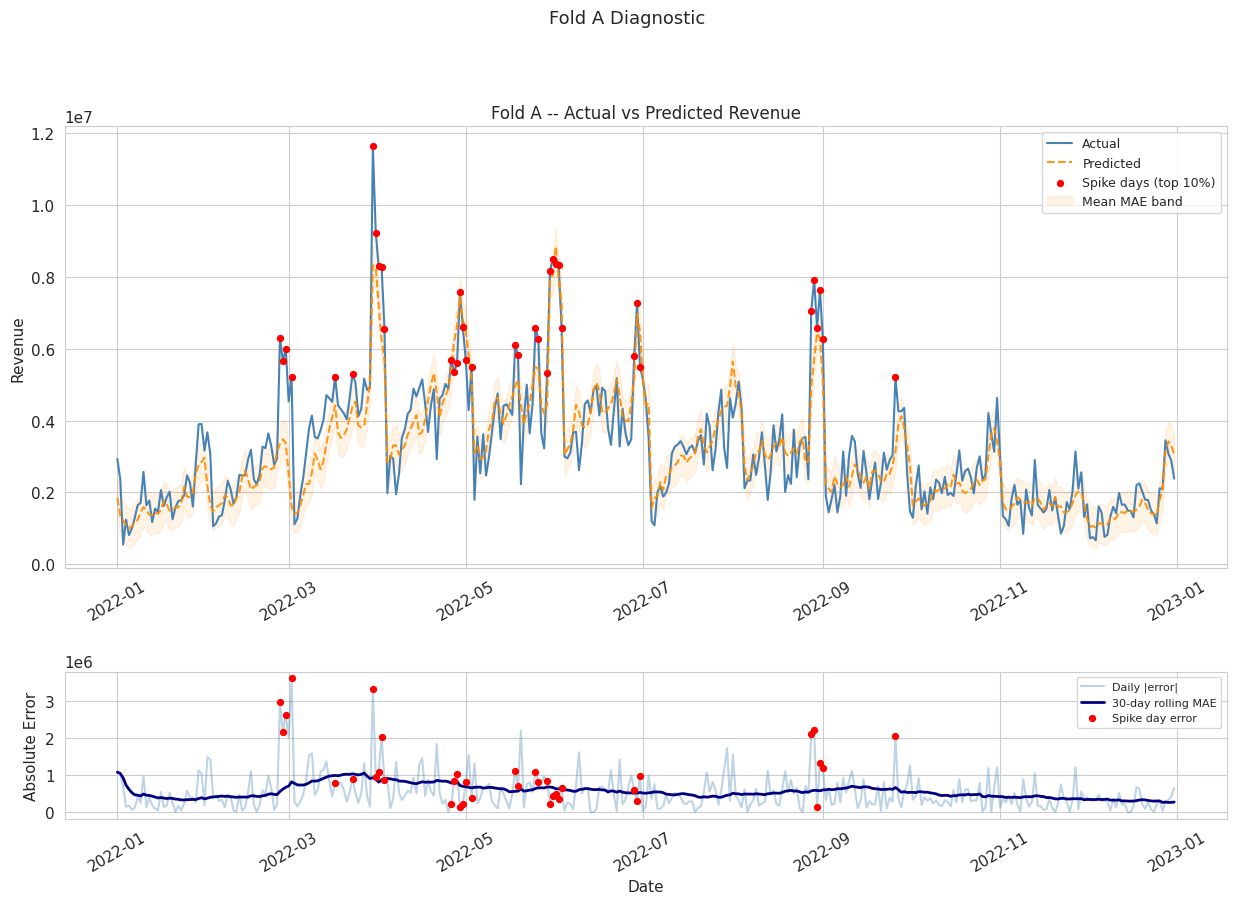

Fold A spike decomposition:
  Spike threshold (p90) : 5,196,156
  Spike days            : 37 / 365
  MAE spike days        : 1,154,818
  MAE normal days       : 481,869
  % total MAE from spikes: 21.3%



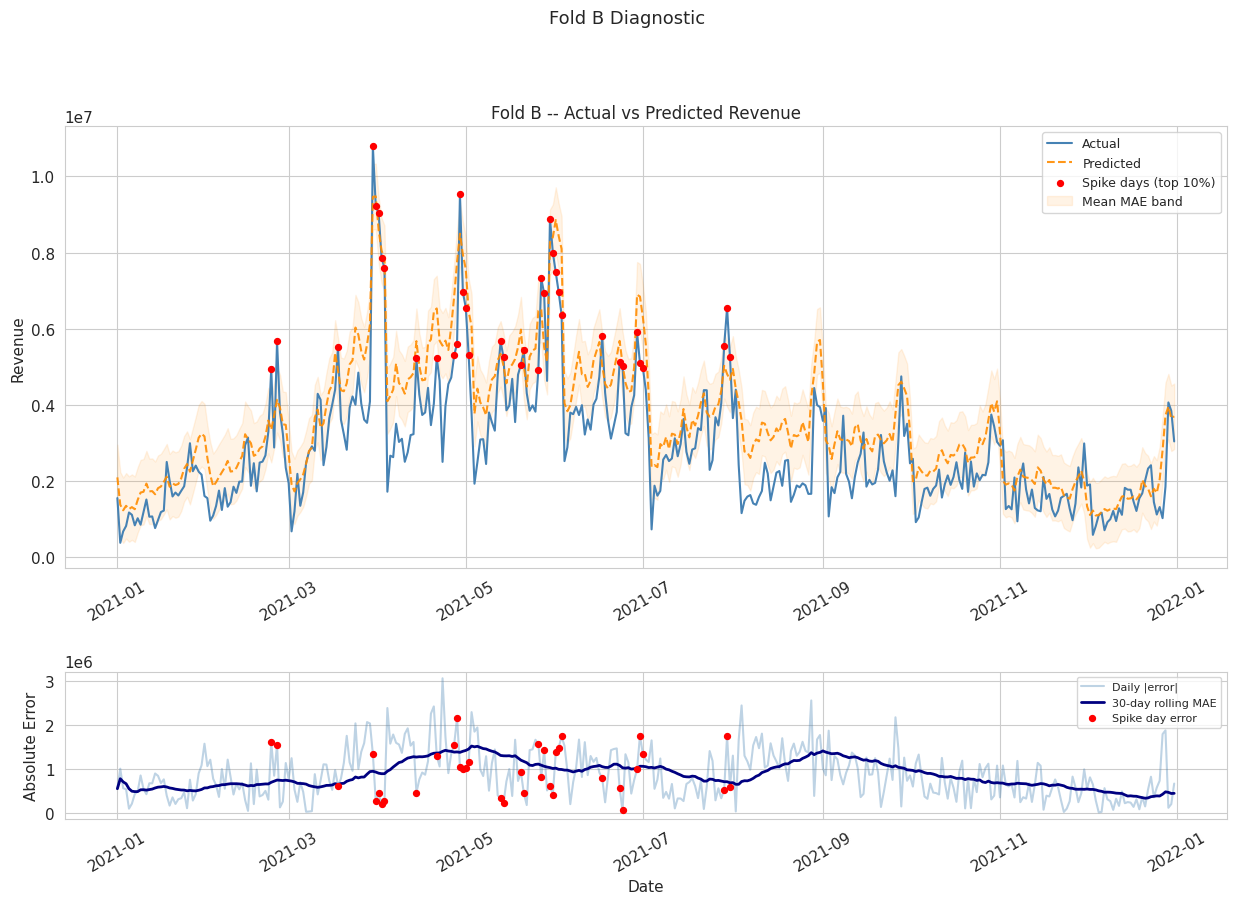

Fold B spike decomposition:
  Spike threshold (p90) : 4,888,347
  Spike days            : 37 / 365
  MAE spike days        : 957,630
  MAE normal days       : 848,609
  % total MAE from spikes: 11.3%



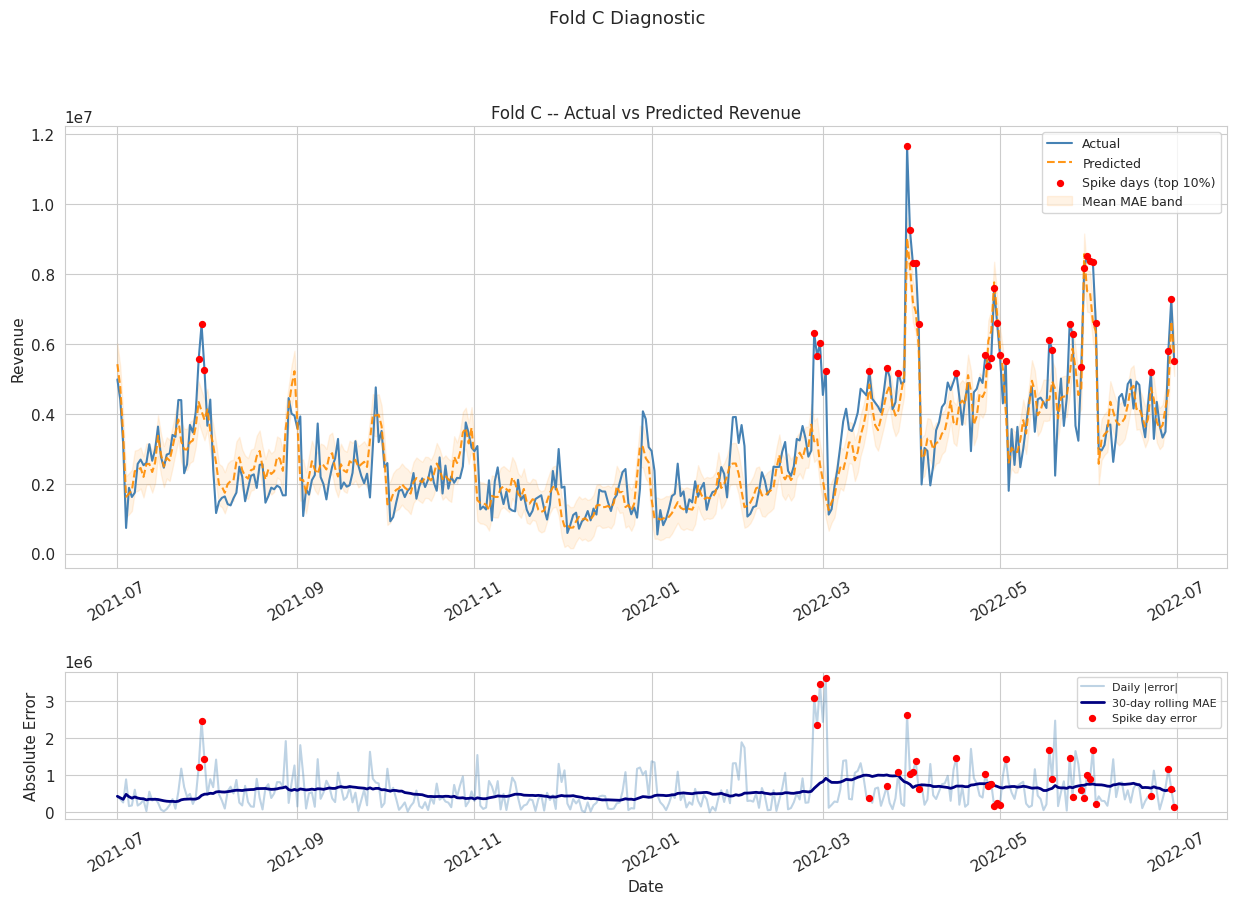

Fold C spike decomposition:
  Spike threshold (p90) : 5,109,582
  Spike days            : 37 / 365
  MAE spike days        : 1,201,326
  MAE normal days       : 518,642
  % total MAE from spikes: 20.7%



In [17]:
visualizer = ModelVisualizer()

# Plot each fold
visualizer.plot_each_fold(results)

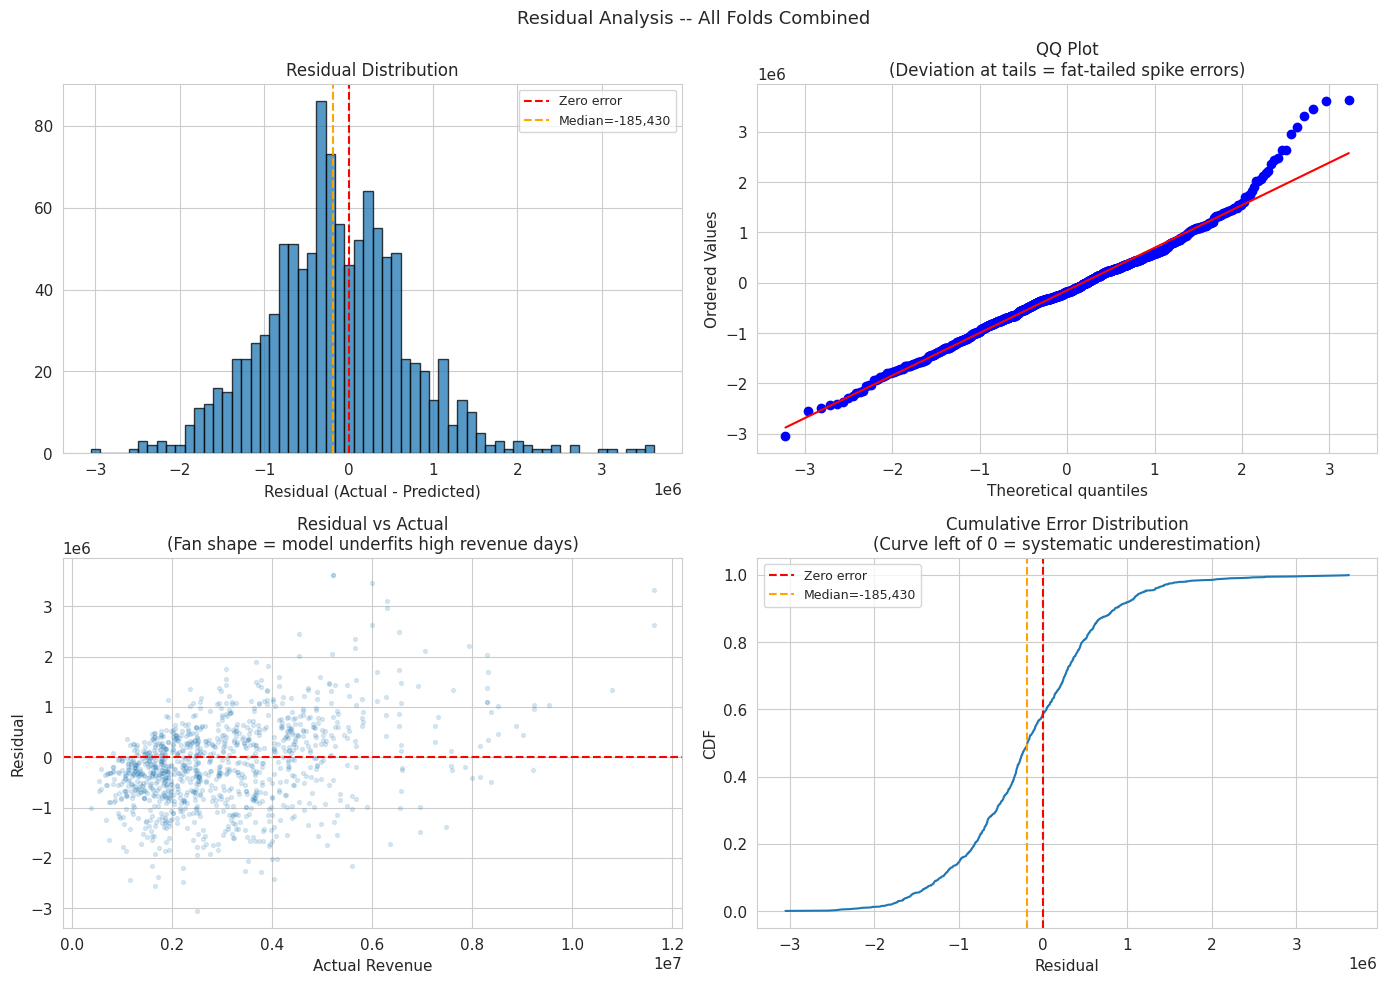

Residual summary (all folds):
  Mean     : -149,799
  Median   : -185,430
  Std      : 850,349
  Skew     : 0.384
  Kurtosis : 1.437


In [18]:
# Residual analysis
visualizer.plot_residuals(results)

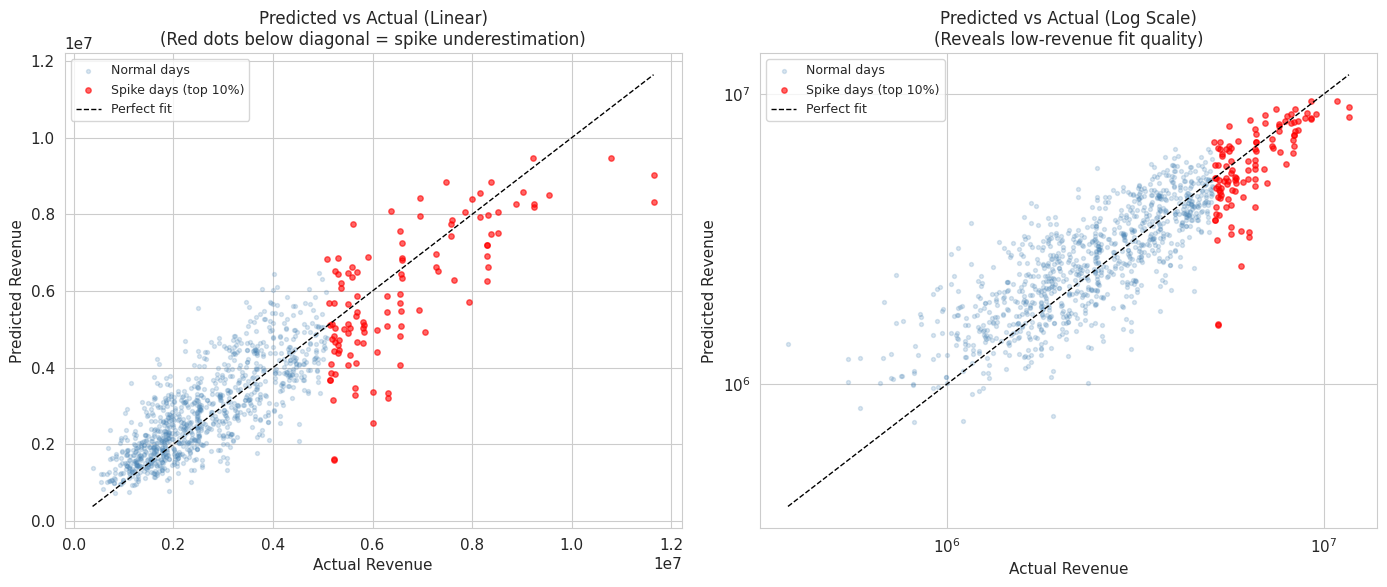

In [19]:
# Scatter plot
visualizer.plot_scatter(results)

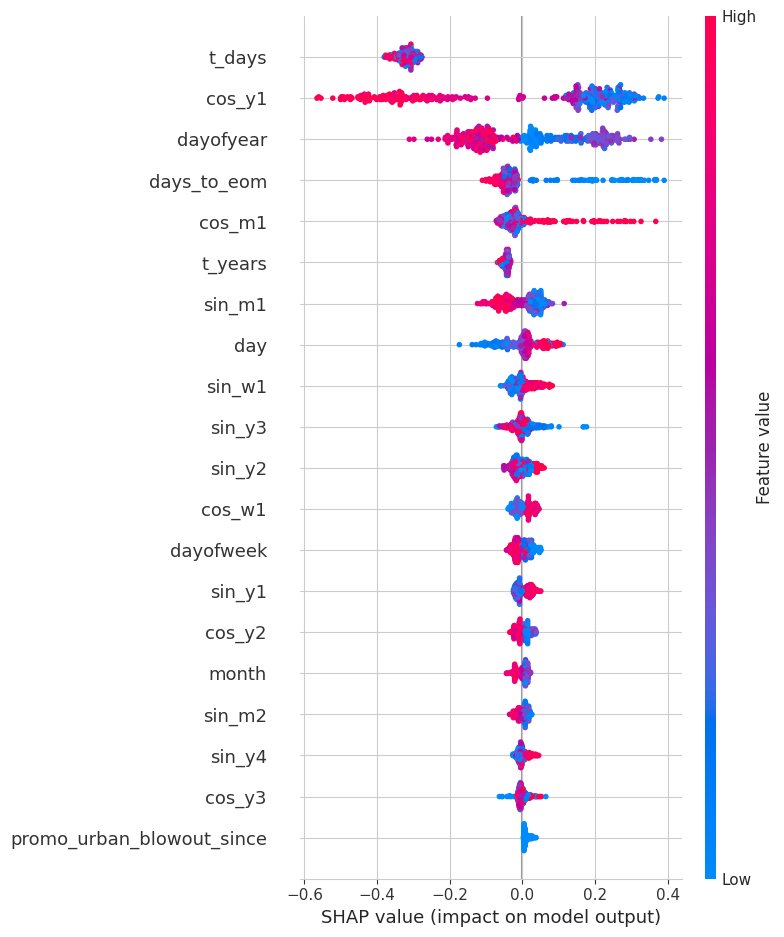

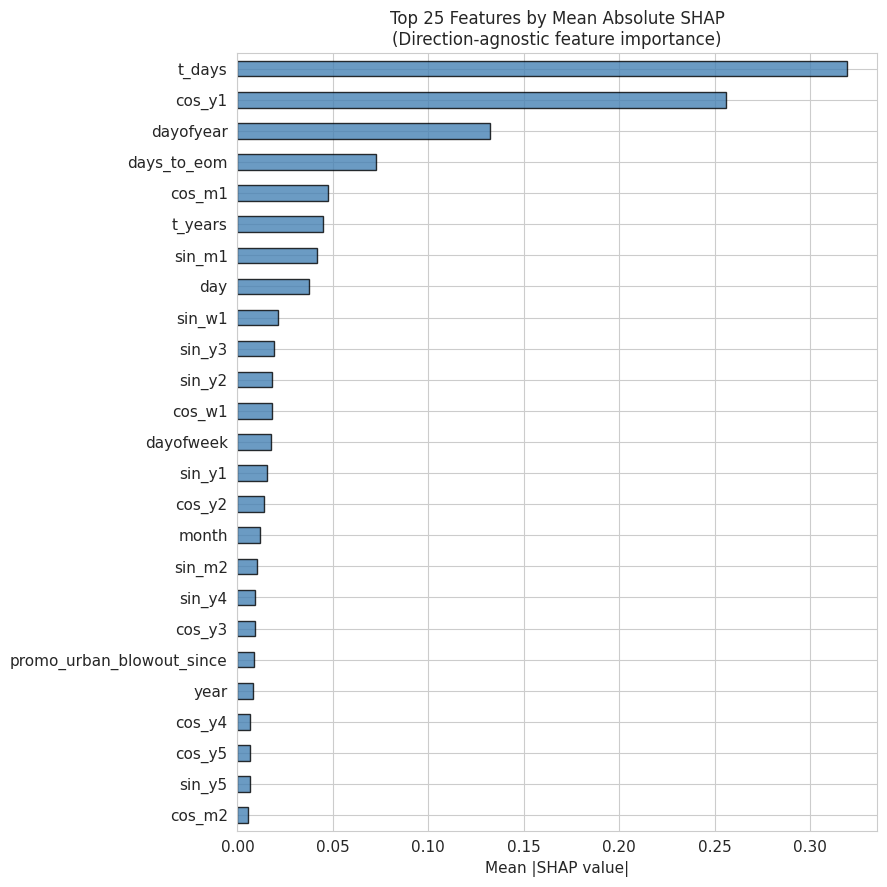

In [20]:
# SHAP summary plot for Fold A

# Use Fold A model and validation set for SHAP since Fold A is the primary fold
visualizer.plot_shap_summary(
    results['A']['model']._lgb_base_rev,
    results['A']['val_df'],
)

# SHAP is computed on the LGB base model for revenue as it carries the highest weight (0.80) in the ensemble
# visualizer.plot_shap_summary(fold_a_model._lgb_base_rev, fold_a_val_df)

In [21]:
# Load foundation models

fm = FoundationModelForecaster(
    context_days      = 512,
    chronos_quantile = 0.5,   # start with median -- tune after diversity analysis
)
fm.load_all()

2026-04-29 22:20:04.186331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777501204.626660     105 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777501204.742067     105 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777501205.775592     105 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777501205.775633     105 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777501205.775636     105 computation_placer.cc:177] computation placer alr

Loading Chronos-2 on cuda...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Chronos-2 loaded.
Loading TimesFM 2.5 on cuda...


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

TimesFM 2.5 PyTorch loaded and compiled.


In [22]:
# Run foundation models on validation Fold A

# Extract Fold A training and validation sets
fold_a_train_df = results['A']['train_df']   # already computed in backtester
fold_a_val_df   = results['A']['val_df']

# Build future feat for Fold A val dates -- needed by Chronos-2 for covariates
fold_a_val_feat = engineer.build_features(
    pd.DatetimeIndex(fold_a_val_df['date'])
)

horizon_a = len(fold_a_val_df)

fm_val = fm.predict_fm(
    train_feat_df  = fold_a_train_df,
    future_feat_df = fold_a_val_feat,
    horizon        = horizon_a,
)

p_chronos2_val = fm_val['chronos2']
p_timesfm_val  = fm_val['timesfm']

Building features...
Feature shape: (365, 82)
Running Chronos-2 inference (post-2019 context only)...
  Chronos-2 done. mean=2,830,218  max=8,212,160
Running TimesFM 2.5 inference (full training history)...
  TimesFM 2.5 done. mean=3,036,648  max=4,969,865


In [23]:
# Diversity analysis on foundation models 

from scipy.stats import pearsonr

fold_a_actual   = fold_a_val_df['revenue'].values
fold_a_ens_pred = results['A']['preds']['revenue'].values

res_ensemble = fold_a_actual - fold_a_ens_pred
mae_ensemble = np.mean(np.abs(res_ensemble))

print("Standalone MAE on Fold A:")
print(f"  Ensemble (current) : {mae_ensemble:,.0f}")

if p_chronos2_val is not None:
    res_chronos2 = fold_a_actual - p_chronos2_val
    mae_chronos2 = np.mean(np.abs(res_chronos2))
    r_chronos2, _ = pearsonr(res_ensemble, res_chronos2)
    print(f"  Chronos-2          : {mae_chronos2:,.0f}")
    print(f"  Error correlation  (Ensemble vs Chronos-2) : {r_chronos2:.3f}")

if p_timesfm_val is not None:
    res_timesfm = fold_a_actual - p_timesfm_val
    mae_timesfm = np.mean(np.abs(res_timesfm))
    r_timesfm, _ = pearsonr(res_ensemble, res_timesfm)
    print(f"  TimesFM            : {mae_timesfm:,.0f}")
    print(f"  Error correlation  (Ensemble vs TimesFM)   : {r_timesfm:.3f}")

# Weight sweep -- directly measures blended MAE at each weight
# This is the ground truth for which weight to use in the final model
print("\nWeight sweep -- Chronos-2:")
for w in [0.0, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20]:
    p_chronos2_val_safe = p_chronos2_val if p_chronos2_val is not None else 0.0
    blended = (1 - w) * fold_a_ens_pred + w * p_chronos2_val_safe
    mae     = np.mean(np.abs(fold_a_actual - blended))
    marker  = " <-- best" if mae < mae_ensemble else ""
    print(f"  w_chronos2={w:.2f} -> MAE: {mae:,.0f}{marker}")

if p_timesfm_val is not None:
    print("\nWeight sweep -- TimesFM:")
    for w in [0.0, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20]:
        blended = (1 - w) * fold_a_ens_pred + w * p_timesfm_val
        mae     = np.mean(np.abs(fold_a_actual - blended))
        marker  = " <-- best" if mae < mae_ensemble else ""
        print(f"  w_timesfm={w:.2f}  -> MAE: {mae:,.0f}{marker}")

Standalone MAE on Fold A:
  Ensemble (current) : 550,086
  Chronos-2          : 745,184
  Error correlation  (Ensemble vs Chronos-2) : 0.513
  TimesFM            : 880,255
  Error correlation  (Ensemble vs TimesFM)   : 0.611

Weight sweep -- Chronos-2:
  w_chronos2=0.00 -> MAE: 550,086
  w_chronos2=0.05 -> MAE: 548,294 <-- best
  w_chronos2=0.08 -> MAE: 547,737 <-- best
  w_chronos2=0.10 -> MAE: 547,526 <-- best
  w_chronos2=0.12 -> MAE: 547,558 <-- best
  w_chronos2=0.15 -> MAE: 548,286 <-- best
  w_chronos2=0.20 -> MAE: 551,865

Weight sweep -- TimesFM:
  w_timesfm=0.00  -> MAE: 550,086
  w_timesfm=0.05  -> MAE: 552,561
  w_timesfm=0.08  -> MAE: 554,746
  w_timesfm=0.10  -> MAE: 556,693
  w_timesfm=0.12  -> MAE: 559,060
  w_timesfm=0.15  -> MAE: 563,563
  w_timesfm=0.20  -> MAE: 571,673


In [24]:
# Fit final model on full training data (2012-01-01 to 2022-12-31)

# Set w_chronos2 and w_timesfm based on diversity analysis results above.
# w_lgb is automatically reduced by the same amount inside predict().
# If diversity analysis showed no benefit for a model, keep its weight at 0.0.

W_CHRONOS2 = 0.10   # replace with best value from weight sweep above
W_TIMESFM  = 0.00   # replace with best value from weight sweep above

final_model = EnsembleForecaster(
    ridge_alpha    = 3.0,
    alpha          = 0.60,
    w_ridge        = 0.10,
    w_prophet      = 0.10,
    w_lgb          = 0.80,
    w_chronos2     = W_CHRONOS2,
    w_timesfm      = W_TIMESFM,
    cal_revenue    = 1.31,   
    cal_cogs       = 1.32,   
    q_boost        = 2.0,
    era_weight     = 1.0,
    off_era_weight = 0.01,
    random_state   = 42,
)

final_model.fit(feat_df, target_rev='revenue', target_cogs='cogs')
print("Final model fitted on full training data (2012-01-01 to 2022-12-31).")

Fitting Ridge (M1)...
Fitting LightGBM base (M2)...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/4q0z21lm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/xnukpa3b.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=41046', 'data', 'file=/tmp/tmpqzdob7xu/4q0z21lm.json', 'init=/tmp/tmpqzdob7xu/xnukpa3b.json', 'output', 'file=/tmp/tmpqzdob7xu/prophet_modellqmcoe4u/prophet_model-20260429222054.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:20:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:20:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Fitting Prophet (M3)...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/yh0ne69v.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/oc6womhm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=37020', 'data', 'file=/tmp/tmpqzdob7xu/yh0ne69v.json', 'init=/tmp/tmpqzdob7xu/oc6womhm.json', 'output', 'file=/tmp/tmpqzdob7xu/prophet_modele8rxm3pk/prophet_model-20260429222059.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:20:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:20:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Fitting quarter specialists...
  Quarter 1...
  Quarter 2...
  Quarter 3...
  Quarter 4...
Fitting complete.
Final model fitted on full training data (2012-01-01 to 2022-12-31).


In [25]:
# Build test feature matrix

# Test period: 2023-01-01 to 2024-07-01 (548 days)
test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')

feat_test = engineer.build_features(test_dates)

print(f"Test feature matrix : {feat_test.shape}")
print(f"Test date range     : {feat_test['date'].min()} -> {feat_test['date'].max()}")
print(f"Test days           : {len(feat_test)}")

Building features...
Feature shape: (548, 82)
Test feature matrix : (548, 82)
Test date range     : 2023-01-01 00:00:00 -> 2024-07-01 00:00:00
Test days           : 548


In [26]:
# Run foundation model inference on the test horizon
fm_test = fm.predict_fm(
    train_feat_df  = feat_df,      # full training data
    future_feat_df = feat_test,    # test features from Block 12
    horizon        = len(feat_test),
)

# Inject into final model before predict()
final_model.set_foundation_predictions(
    p_chronos2 = fm_test['chronos2'],
    p_timesfm  = fm_test['timesfm'],
)

print("Foundation predictions injected into final model.")

Running Chronos-2 inference (post-2019 context only)...
  Chronos-2 done. mean=2,461,074  max=5,473,286
Running TimesFM 2.5 inference (full training history)...
  TimesFM 2.5 done. mean=2,668,251  max=5,297,282
Foundation predictions injected into final model.


In [27]:
# Generate final forecast for submission

forecast = final_model.predict(feat_test)

print(f"Forecast shape : {forecast.shape}")
print(f"\nForecast summary:")
print(f"  Revenue -- mean: {forecast['revenue'].mean():,.0f}  "
      f"max: {forecast['revenue'].max():,.0f}  "
      f"min: {forecast['revenue'].min():,.0f}")
print(f"  COGS    -- mean: {forecast['cogs'].mean():,.0f}  "
      f"max: {forecast['cogs'].max():,.0f}  "
      f"min: {forecast['cogs'].min():,.0f}")
print(forecast.head(10))

Forecast shape : (548, 3)

Forecast summary:
  Revenue -- mean: 4,058,070  max: 10,798,525  min: 1,156,901
  COGS    -- mean: 3,734,558  max: 10,185,509  min: 1,055,164
        date       revenue          cogs
0 2023-01-01  2.409217e+06  2.544832e+06
1 2023-01-02  1.791201e+06  1.769017e+06
2 2023-01-03  1.519037e+06  1.414198e+06
3 2023-01-04  1.156901e+06  1.055164e+06
4 2023-01-05  1.350614e+06  1.202418e+06
5 2023-01-06  1.548985e+06  1.463371e+06
6 2023-01-07  1.550454e+06  1.456527e+06
7 2023-01-08  1.716238e+06  1.675468e+06
8 2023-01-09  2.168407e+06  2.029062e+06
9 2023-01-10  2.038007e+06  1.888886e+06


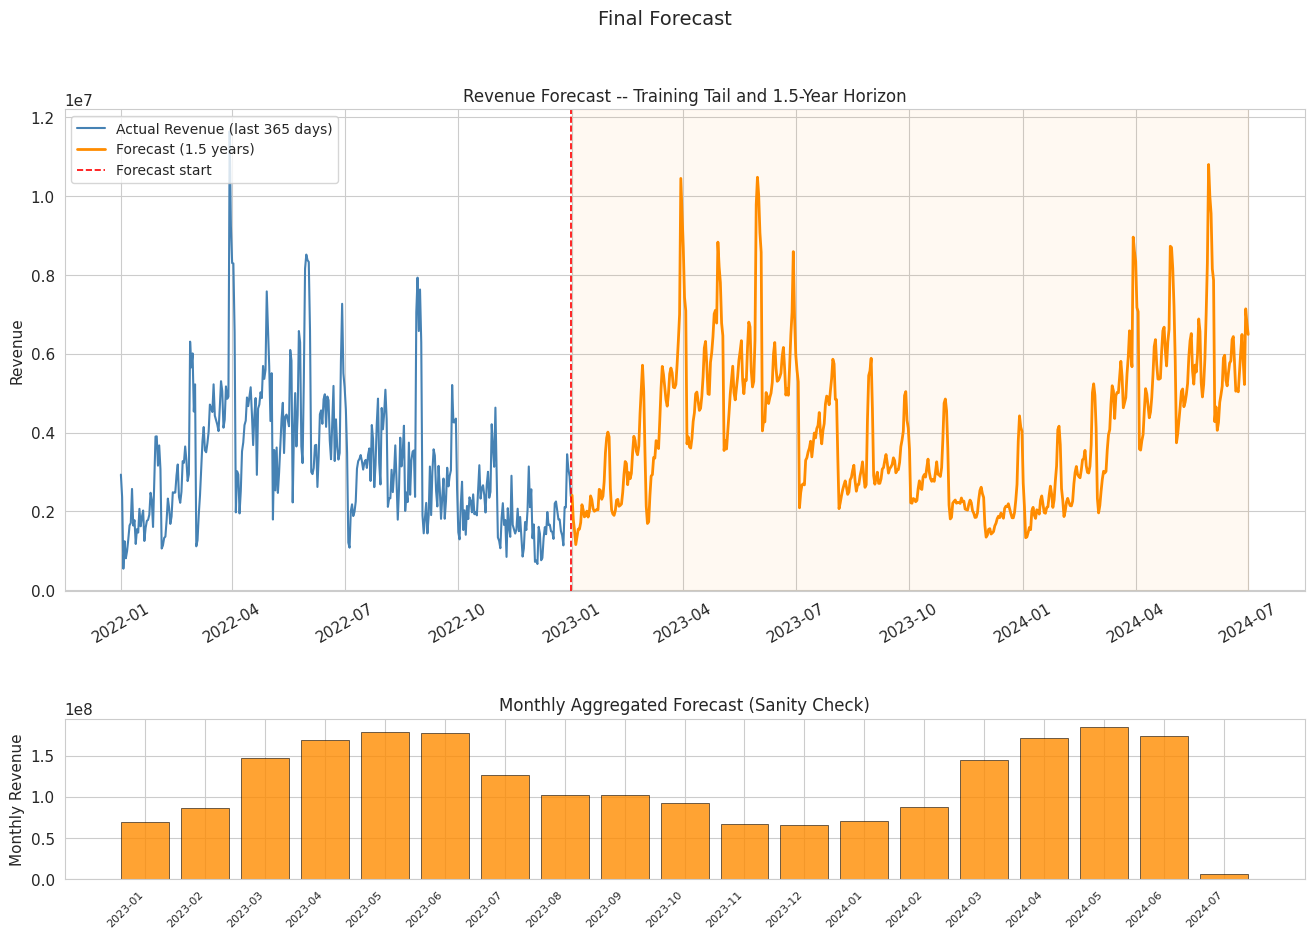

Forecast summary:
  Period     : 2023-01-01 00:00:00 -> 2024-07-01 00:00:00
  Days       : 548
  Total rev  : 2,223,822,098
  Daily avg  : 4,058,070
  Daily max  : 10,798,525
  Daily min  : 1,156,901
  Zero days  : 0


In [28]:
# Plot full forecast

visualizer.plot_forecast(
    train_df       = feat_df,
    feat_test        = feat_test,
    forecast_df    = forecast,
    date_col       = 'date',
    target_col     = 'revenue',
    train_tail_days = 365,
)

In [29]:
# Export Submission to CSV

submission = pd.DataFrame({
    'Date'   : forecast['date'].dt.strftime('%Y-%m-%d'),
    'Revenue': forecast['revenue'].round(2),
    'COGS'   : forecast['cogs'].round(2),
})

assert len(submission) == 548, f"Expected 548 rows, got {len(submission)}"
assert submission['Revenue'].isna().sum() == 0, "Revenue contains NaN"
assert submission['COGS'].isna().sum() == 0, "COGS contains NaN"
assert (submission['Revenue'] >= 0).all(), "Revenue contains negative values"
assert (submission['COGS'] >= 0).all(), "COGS contains negative values"

submission.to_csv('/kaggle/working/submission.csv', index=False)

print(f"Submission saved: {len(submission)} rows")
print(submission.head(10))

Submission saved: 548 rows
         Date     Revenue        COGS
0  2023-01-01  2409216.54  2544832.16
1  2023-01-02  1791201.23  1769017.45
2  2023-01-03  1519037.07  1414198.14
3  2023-01-04  1156900.83  1055163.97
4  2023-01-05  1350613.67  1202418.11
5  2023-01-06  1548984.84  1463371.24
6  2023-01-07  1550454.21  1456527.40
7  2023-01-08  1716238.35  1675467.65
8  2023-01-09  2168407.33  2029062.43
9  2023-01-10  2038007.35  1888885.67


In [30]:
# Calibration Sweep 

# After the first submission with cal_revenue=1.26, cal_cogs=1.32,
# sweep the calibration factors independently around the values
# to find the leaderboard optimum for this specific run.
#
# Procedure:
#   1. Fix cal_cogs at 1.32, sweep cal_revenue in CR_RANGE -> submit each
#   2. Fix cal_revenue at best found value, sweep cal_cogs in CC_RANGE -> submit each
#   3. Fine-tune the winning pair with step 0.01
'''
CR_RANGE = [1.18, 1.20, 1.22, 1.24, 1.26, 1.28, 1.30, 1.32]
CC_RANGE = [1.28, 1.30, 1.32, 1.34, 1.36]

for cr in CR_RANGE:
    sweep_model = EnsembleForecaster(
        ridge_alpha    = 3.0,
        alpha          = 0.60,
        w_ridge        = 0.10,
        w_prophet      = 0.10,
        w_lgb          = 0.80,
        cal_revenue    = cr,
        cal_cogs       = 1.32,
        q_boost        = 2.0,
        era_weight     = 1.0,
        off_era_weight = 0.01,
        random_state   = 42,
    )
    sweep_model.fit(feat_df)
    sweep_forecast = sweep_model.predict(feat_test)

    out = pd.DataFrame({
        'Date'   : sweep_forecast['date'].dt.strftime('%Y-%m-%d'),
        'Revenue': sweep_forecast['revenue'].round(2),
        'COGS'   : sweep_forecast['cogs'].round(2),
    })
    out.to_csv(f'/kaggle/working/submission_cr{cr}_cc_1.32.csv', index=False)
    print(f"Saved: cr={cr}, cc=1.32")
'''

Fitting Ridge (M1)...
Fitting LightGBM base (M2)...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/fvfpmo7e.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/a_4lbe4h.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73920', 'data', 'file=/tmp/tmpqzdob7xu/fvfpmo7e.json', 'init=/tmp/tmpqzdob7xu/a_4lbe4h.json', 'output', 'file=/tmp/tmpqzdob7xu/prophet_modelnxn6uetf/prophet_model-20260429222140.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:21:40 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:21:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Fitting Prophet (M3)...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/8bv70bsx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/4oqkbx4n.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11509', 'data', 'file=/tmp/tmpqzdob7xu/8bv70bsx.json', 'init=/tmp/tmpqzdob7xu/4oqkbx4n.json', 'output', 'file=/tmp/tmpqzdob7xu/prophet_modelz8w6ucto/prophet_model-20260429222141.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:21:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:21:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Fitting quarter specialists...
  Quarter 1...
  Quarter 2...
  Quarter 3...
  Quarter 4...
Fitting complete.
Saved: cr=1.18, cc=1.32
Fitting Ridge (M1)...
Fitting LightGBM base (M2)...


...

Fitting quarter specialists...
  Quarter 1...
  Quarter 2...
  Quarter 3...
  Quarter 4...
Fitting complete.
Saved: cr=1.3, cc=1.32
Fitting Ridge (M1)...
Fitting LightGBM base (M2)...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/0m2prjrj.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/nnwvlm9h.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47677', 'data', 'file=/tmp/tmpqzdob7xu/0m2prjrj.json', 'init=/tmp/tmpqzdob7xu/nnwvlm9h.json', 'output', 'file=/tmp/tmpqzdob7xu/prophet_modelst9vzob0/prophet_model-20260429222630.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:26:30 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


Fitting Prophet (M3)...


22:26:30 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/wvm23pgh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpqzdob7xu/cbf90tv0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=36289', 'data', 'file=/tmp/tmpqzdob7xu/wvm23pgh.json', 'init=/tmp/tmpqzdob7xu/cbf90tv0.json', 'output', 'file=/tmp/tmpqzdob7xu/prophet_modelreffjw8d/prophet_model-20260429222630.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:26:30 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:26:30 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Fitting quarter specialists...
  Quarter 1...
  Quarter 2...
  Quarter 3...
  Quarter 4...
Fitting complete.
Saved: cr=1.32, cc=1.32
